# Comparison of marker hinge motion distances for apo AK2 | Figure 2

## MD-based distance distribution - Figure 2A (left)

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

def plot_distance_normalized_frequency(csv_file,
                                              bin_width=0.375,
                                              x_min=2.0,
                                              x_max=22.0,
                                              title='Distance Frequency',
                                              color='#6DA5ED',
                                              edgecolor='#2866A3',
                                              output_filename=None):
    """
    Plot a normalized histogram for a single CSV file of distances.
    Also prints the mean and median of the distances.

    Args:
        csv_file (str): Path to the CSV file. Must contain a 'Distance' column.
        bin_width (float): Bin width for histogram. Default is 0.375 Å.
        x_min (float): Minimum x-axis value. Default is 2.0 Å.
        x_max (float): Maximum x-axis value. Default is 22.0 Å.
        title (str): Title of the plot.
        color (str): Fill color of the bars.
        edgecolor (str): Edge color of the bars.
        output_filename (str, optional): Output filename (with or without .png).
    """
    # Load data
    df = pd.read_csv(csv_file)
    distances = df['Distance']

    # Calculate statistics
    mean_val = distances.mean()
    median_val = distances.median()

    print(f"Mean distance: {mean_val:.2f} Å")
    print(f"Median distance: {median_val:.2f} Å")

    # Create bins
    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Histogram
    freq, _ = np.histogram(distances, bins=bin_edges)
    norm_freq = freq / len(distances)

    # Plotting
    plt.figure(figsize=(10, 8))
    plt.bar(bin_centers, norm_freq, width=bin_width,
            color=color, edgecolor=edgecolor, linewidth=2, alpha=0.6)

    # Decorations
    plt.title(title, fontsize=18, pad=20)
    plt.xlabel('Distance (Å)', fontsize=16)
    plt.ylabel('Probability', fontsize=16)
    plt.xticks([5, 10, 15, 20], fontsize=24)
    plt.yticks(fontsize=24)
    plt.axvline(x=5.86, color='red', linestyle='--', linewidth=3)
    plt.axvline(x=9.97, color='black', linestyle='--', linewidth=3)
    #plt.ylim(0, 0.6) #used for MD distance distribution
    plt.ylim(0, 1.0) 
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()

    # Save figure
    if output_filename is None:
        base_dir = os.path.dirname(csv_file)
        grandparent = os.path.basename(os.path.dirname(base_dir))
        target = os.path.basename(base_dir)
        output_filename = f"normalized_histogram_{grandparent}_{target}.png"
    elif not output_filename.endswith(".png"):
        output_filename += ".png"

    output_path = os.path.join(os.path.dirname(csv_file), output_filename)
    plt.savefig(output_path, dpi=300)
    plt.show()


Mean distance: 5.93 Å
Median distance: 5.86 Å


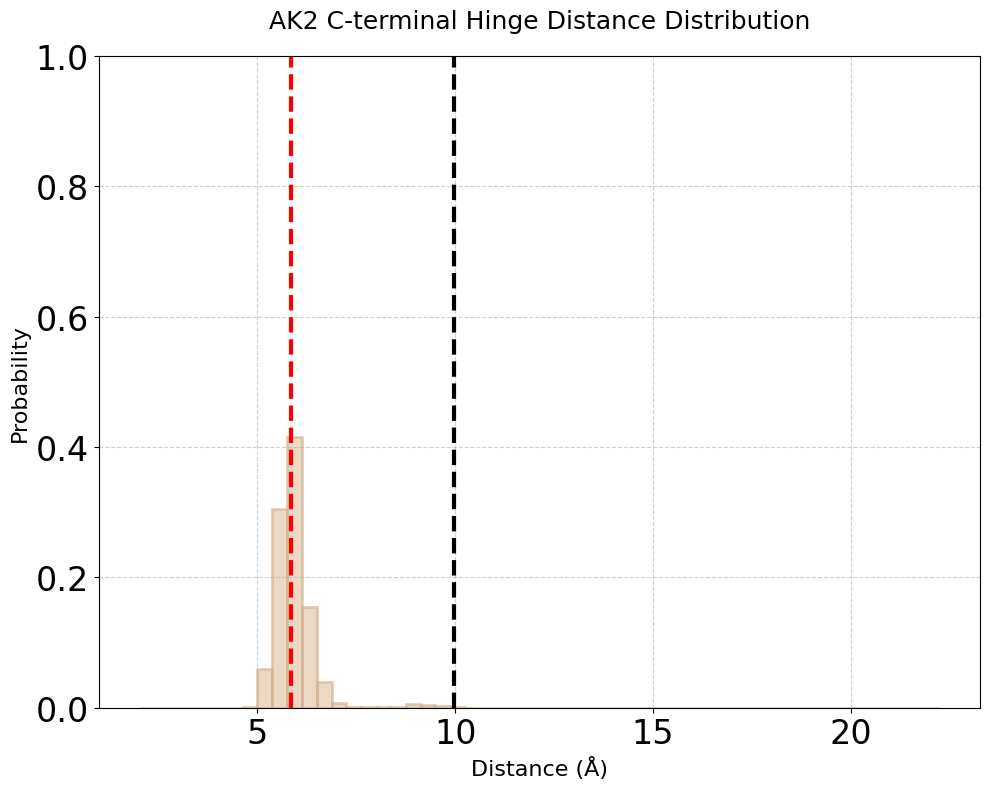

In [25]:
plot_distance_normalized_frequency(
    csv_file="/Volumes/Expansion/FEBS/MD/230_233_apo_merged.dist",
    title="AK2 C-terminal Hinge Distance Distribution",
    color="#E1C09C",
    edgecolor="#D1AD89",
    output_filename="230_233_apo_merged"
)

## AF-based Distograms

In [26]:
import os
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
import pickle
from matplotlib.ticker import FuncFormatter

def plot_all_distograms_in_directory(directory_path, res_i=230, res_j=233, temperature=1.0, title=None, output_filename=None):
    """
    Plot distograms for residue pair (res_i, res_j) from all .npz or .pkl files in a directory.

    Args:
        directory_path (str): Path to the folder containing distogram .npz or .pkl files.
        res_i (int): Residue index i (1-based biological indexing).
        res_j (int): Residue index j (1-based biological indexing).
        temperature (float): Temperature scaling for logits -> probability conversion.
        title (str, optional): Custom title for the plot. Defaults to a standard title.
        output_filename (str, optional): The filename for the saved plot (e.g., 'my_plot.png'). 
                                          If None, a default filename will be generated.
    """
    file_paths = sorted(glob(os.path.join(directory_path, "*.npz")) + 
                        glob(os.path.join(directory_path, "*.pkl")) +
                        glob(os.path.join(directory_path, "*.pickle")))

    if not file_paths:
        print(f"No .npz, .pkl, or .pickle files found in {directory_path}")
        return

    # Define bin centers and edges for AlphaFold's 64-bin distogram
    bin_edges = np.arange(2.0, 22.1875 + 0.3125, 0.3125)[:65]
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    plt.figure(figsize=(10, 8))
    colors = plt.cm.Spectral(np.linspace(0, 1, len(file_paths)))

    for i, file_path in enumerate(file_paths):
        logits = None

        # --- File Loading Logic ---
        if file_path.endswith(".npz"):
            try:
                data = np.load(file_path, allow_pickle=True)
                logits = data.get('logits', None)
                if logits is None:
                    dgram = data.get('distogram', None)
                    if isinstance(dgram, dict) and 'logits' in dgram:
                        logits = dgram['logits']
                    elif isinstance(dgram, np.ndarray):
                        # Assuming a direct distogram array is the logits
                        logits = dgram
            except Exception as e:
                print(f"Error loading {file_path}: {e}")
                continue

        elif file_path.endswith((".pkl", ".pickle")):
            try:
                with open(file_path, "rb") as f:
                    data = pickle.load(f)
                    if 'logits' in data:
                        logits = data['logits']
                    elif 'distogram' in data:
                        dgram = data['distogram']
                        if isinstance(dgram, dict) and 'logits' in dgram:
                            logits = dgram['logits']
                        elif isinstance(dgram, np.ndarray):
                            logits = dgram
            except Exception as e:
                print(f"Error loading {file_path}: {e}")
                continue
        # --- End File Loading Logic ---

        if logits is None:
            print(f"No logits/distogram found in {file_path}")
            continue

        # Convert logits to probability using softmax (handling potential large values)
        scaled_logits = logits / temperature
        # Use a numerically stable softmax
        exp_logits = np.exp(scaled_logits - np.max(scaled_logits, axis=-1, keepdims=True))
        probs = exp_logits / np.sum(exp_logits, axis=-1, keepdims=True)

        # Extract residue pair (0-based index: res_i - 1, res_j - 1)
        try:
            probs_res = probs[res_i - 1, res_j - 1, :]
        except IndexError:
            print(f"Index error in {file_path}: shape={logits.shape}, requested=({res_i},{res_j}). Skipping.")
            continue

        label = os.path.basename(file_path).replace(".npz", "").replace(".pkl", "").replace(".pickle", "")
        plt.plot(bin_centers, probs_res, label=label, color=colors[i], linewidth=2)

    # --- Plot Customization ---
    if title is None:
        title = f"Distogram - Residue {res_i} vs {res_j}"
    plt.title(title, fontsize=18, pad=20)
    plt.xlabel("Distance (Å)", fontsize=16)
    plt.ylabel("Probability", fontsize=16)
    plt.ylim(0, 0.6)
    
    # Adjusted tick sizes for better visualization
    plt.xticks([5, 10, 15, 20], fontsize=24) 
    plt.yticks(fontsize=24)
    
    # Example distance lines (often used for contact thresholds)
    plt.axvline(x=5.86, color='red', linestyle='--', linewidth=3)
    plt.axvline(x=9.97, color='black', linestyle='--', linewidth=3)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.1f}")) 
    #plt.legend(fontsize=12, loc="best")
    plt.tight_layout()

    # --- Output Filename Logic (Updated) ---
    if output_filename:
        # If provided, use the input filename and save in the directory's parent folder
        output_dir = os.path.dirname(os.path.dirname(directory_path))
        if not output_dir:
            # Fallback to current working directory if directory_path has no parent
            output_dir = "."
        final_output_path = os.path.join(output_dir, output_filename)
    else:
        # Retain original default filename generation if no output_filename is provided
        base_dir = os.path.dirname(directory_path)
        grandparent = os.path.basename(os.path.dirname(base_dir))
        target = os.path.basename(base_dir)
        default_filename = f"distogram_distribution_{grandparent}_{target}_res{res_i}_{res_j}.png"
        final_output_path = os.path.join(os.path.dirname(base_dir), default_filename)

    plt.savefig(final_output_path, dpi=300)
    print(f"Plot saved to: {final_output_path}")
    plt.show()

### AlphaFold2 (ptm) distogram | Figure 2 (middle)

Plot saved to: /Volumes/Expansion/FEBS/af2-ptm/distogram_distribution_af2-ptm_ak2-seed5_res230_233.png


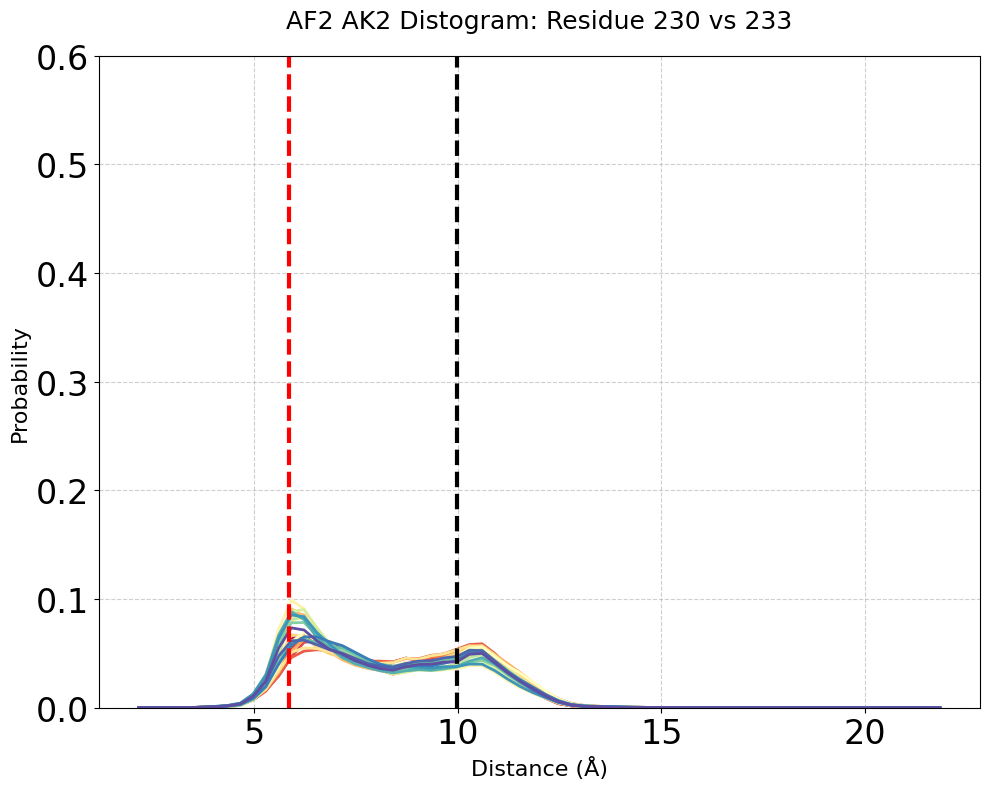

In [27]:
res_i = 230
res_j = 233
plot_all_distograms_in_directory(
    "/Volumes/Expansion/FEBS/af2-ptm/ak2-seed5/distograms",
    res_i=res_i,
    res_j=res_j,
    title=f"AF2 AK2 Distogram: Residue {res_i} vs {res_j}"
)

### AlphaFold3 distogram | Figure 2 (right)

Plot saved to: /Volumes/Expansion/FEBS/af3/ak2/distogram_distribution_ak2_25-seeds_res230_233.png


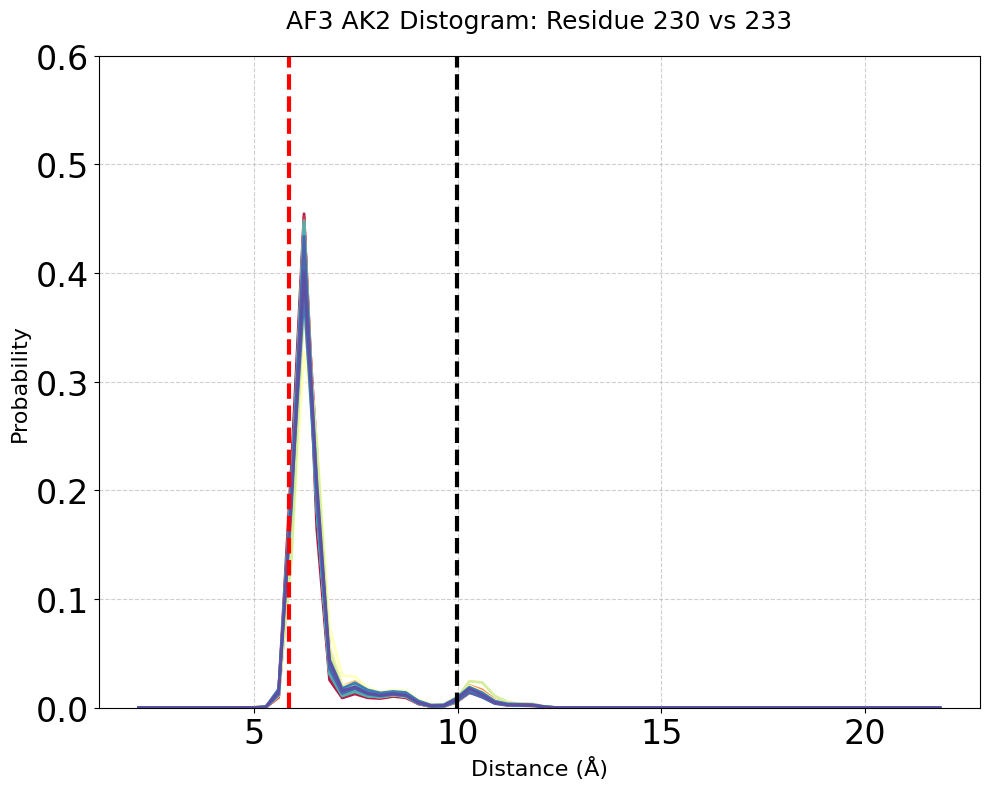

In [28]:
res_i = 230
res_j = 233
plot_all_distograms_in_directory(
    "/Volumes/Expansion/FEBS/af3/ak2/25-seeds/distograms",
    res_i=res_i,
    res_j=res_j,
    title=f"AF3 AK2 Distogram: Residue {res_i} vs {res_j}"
)

### MinnieFold distograms | Figure 2B (top)

Plot saved to: /Volumes/Expansion/FEBS/minniefold/distogram_distribution_minniefold_ak2_res230_233.png


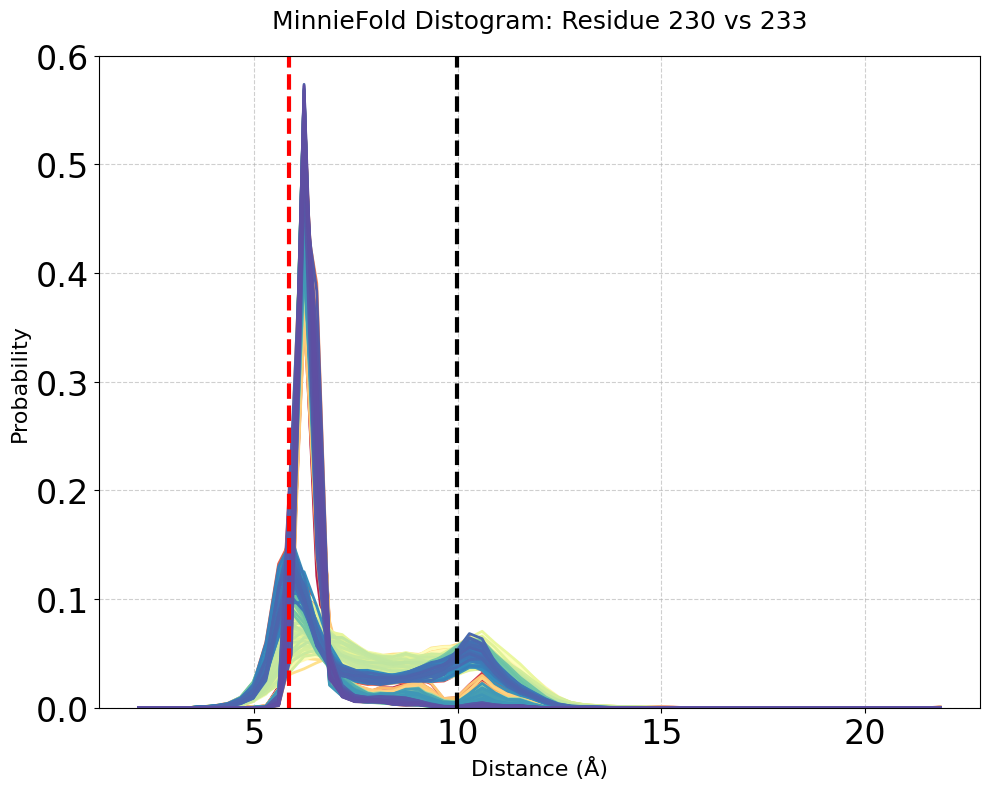

In [30]:
res_i = 230
res_j = 233
plot_all_distograms_in_directory(
    "/Volumes/Expansion/FEBS/minniefold/ak2/distograms",
    res_i=res_i,
    res_j=res_j,
    title=f"MinnieFold Distogram: Residue {res_i} vs {res_j}"
)

### MinnieFold distograms per version | Figure 2B (bottom)

In [31]:
import os
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
import pickle
from collections import defaultdict
import re
# Import for Spectral colormap
from matplotlib import cm 

# Scenario-to-recycle mapping
scenario_to_recycles = {
    1: 3, 2: 3, 3: 3, 4: 3, 5: 3, 6: 3,
    7: 9, 9: 9, 11: 9, 13: 9, 15: 9, 17: 9, 21: 9, 23: 9,
    8: 21, 10: 21, 12: 21, 14: 21, 16: 21, 18: 21, 22: 21, 24: 21,
    19: 3, 20: 3
}

# Colors per version (used for default theme/title color)
version_colors = {
    "ptm": "#AA60C8",  # purple
    "v1": "#4FBDBA",   # teal
    "v2": "#E88A1A",   # orange
    "v3": "#B1BD5D"    # olive
}

# Custom subplot titles
version_titles = {
    "ptm": "AF2-ptm",
    "v1": "AF-v2.1",
    "v2": "AF-v2.2",
    "v3": "AF-v2.3"
}

def extract_recycle_from_scenario(filename):
    """Extract scenario number from filename and map to recycle count."""
    match = re.search(r'scenario(\d+)', filename)
    if match:
        scenario_num = int(match.group(1))
        return scenario_to_recycles.get(scenario_num)
    return None

def plot_all_distograms_by_version(
    directory_path, res_i=230, res_j=233, temperature=1.0,
    title=None, output_path="distogram_versions_plot.png"
):
    """
    Plot 2x2 grid of distogram probability profiles by AlphaFold version.
    Individual runs within each version are colored using the Spectral colormap.

    Args:
        directory_path (str): Path to .npz or .pickle distogram files.
        res_i, res_j (int): Residue indices (1-based).
        temperature (float): Logit scaling.
        title (str): Figure title.
        output_path (str): File path to save the figure.
    """
    file_paths = sorted(glob(os.path.join(directory_path, "*.npz")) +
                        glob(os.path.join(directory_path, "*.pickle")))

    if not file_paths:
        print(f"No distogram files found in {directory_path}")
        return

    # Categorize files by version
    categorized_files = defaultdict(list)
    for path in file_paths:
        if "_ptm_" in path:
            categorized_files["ptm"].append(path)
        elif "_v1_" in path:
            categorized_files["v1"].append(path)
        elif "_v2_" in path:
            categorized_files["v2"].append(path)
        elif "_v3_" in path:
            categorized_files["v3"].append(path)

    versions = ["ptm", "v1", "v2", "v3"]
    fig, axes = plt.subplots(2, 2, figsize=(16, 14), sharex=True, sharey=True)
    axes = axes.flatten()

    # Define bin centers and edges
    # Standard AlphaFold bin count (64 bins)
    bin_edges = np.arange(2.0, 22.0 + 0.3125, 0.3125)[:65] 
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    for i, version in enumerate(versions):
        ax = axes[i]
        files = categorized_files.get(version, [])
        num_files = len(files)
        
        # Get the Spectral colormap and map colors based on the number of files
        spectral_cmap = cm.get_cmap('Spectral')
        
        # Use a consistent color for the subplot title based on the version_colors map
        title_color = version_colors.get(version, "#999999") 

        if not files:
            ax.set_title(f"{version_titles.get(version, version.upper())}\n(No data)", 
                         fontsize=16, color=title_color)
            ax.set_ylim(0, 0.6) # Ensure empty plot has correct limits
            continue

        for j, file_path in enumerate(files):
            logits = None
            
            # Use Spectral coloring for individual lines
            # Normalize index j across the total number of files in this version
            line_color = spectral_cmap(j / (num_files - 1) if num_files > 1 else 0.5) 
            
            # --- Robust File Loading Logic ---
            try:
                if file_path.endswith(".npz"):
                    data = np.load(file_path, allow_pickle=True)
                    if isinstance(data, np.ndarray):
                        logits = data
                    elif hasattr(data, 'get'):
                        logits = data.get('logits', None)
                        if logits is None:
                            dgram = data.get('distogram', None)
                            if isinstance(dgram, dict) and 'logits' in dgram:
                                logits = dgram['logits']
                            elif isinstance(dgram, np.ndarray):
                                logits = dgram
                        if logits is None and 'arr_0' in data:
                            logits = data['arr_0']
                
                elif file_path.endswith(".pickle"):
                    with open(file_path, "rb") as f:
                        data = pickle.load(f)
                        logits = data.get('logits')
                        if logits is None and 'distogram' in data:
                            dgram = data['distogram']
                            logits = dgram.get('logits') if isinstance(dgram, dict) else dgram
            
            except Exception as e:
                print(f"Error loading {file_path}: {e}")
                continue

            # Basic Logits Validation
            if logits is None or not isinstance(logits, np.ndarray) or logits.ndim < 3 or logits.shape[-1] != 64:
                 print(f"Skipping {os.path.basename(file_path)}. Invalid logits data structure.")
                 continue

            # Softmax to convert logits to probabilities
            scaled_logits = logits / temperature
            exp_logits = np.exp(scaled_logits - np.max(scaled_logits, axis=-1, keepdims=True))
            probs = exp_logits / np.sum(exp_logits, axis=-1, keepdims=True)

            try:
                probs_res = probs[res_i - 1, res_j - 1, :]
            except IndexError:
                print(f"Index error in {os.path.basename(file_path)}: requested=({res_i},{res_j}) out of range.")
                continue

            # Plot with Spectral color
            ax.plot(bin_centers, probs_res, color=line_color, alpha=0.8, linewidth=2)
            
            # Add vertical dashed reference lines (inside the loop so they are drawn per-subplot)
            ax.axvline(x=5.86, color='red', linestyle='--', linewidth=3, alpha=0.6)
            ax.axvline(x=9.97, color='black', linestyle='--', linewidth=3, alpha=0.6)


        # Formatting
        ax.set_title(version_titles.get(version, version.upper()), fontsize=48, pad=30, color=title_color)
        ax.set_ylabel("Probability", fontsize=32)
        ax.set_xticks([5, 10, 15, 20])
        ax.set_yticks(np.linspace(0, 0.6, 4)) # Adjusted for better tick density given ylim
        ax.tick_params(axis='both', which='major', labelsize=28)
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.set_ylim(0, 0.6) # Enforce consistent y-limit

    # Apply shared X-label to all axes (using label_outer to only draw on bottom row)
    for ax in axes:
        ax.set_xlabel("Distance (Å)", fontsize=32)
        ax.label_outer()

    if title:
        fig.suptitle(title, fontsize=30, y=0.98) # Increased font size and moved up slightly

    # Note: I commented out the version legend code to prevent crowding, 
    # as the titles are now colored and prominent.

    plt.tight_layout(rect=[0, 0, 1, 0.95] if title else None)
    plt.savefig(output_path, dpi=300)
    print(f"Plot saved to: {output_path}")
    plt.show()

Plot saved to: /Volumes/Expansion/FEBS/minniefold/ak2/distogram_versions_plot.png


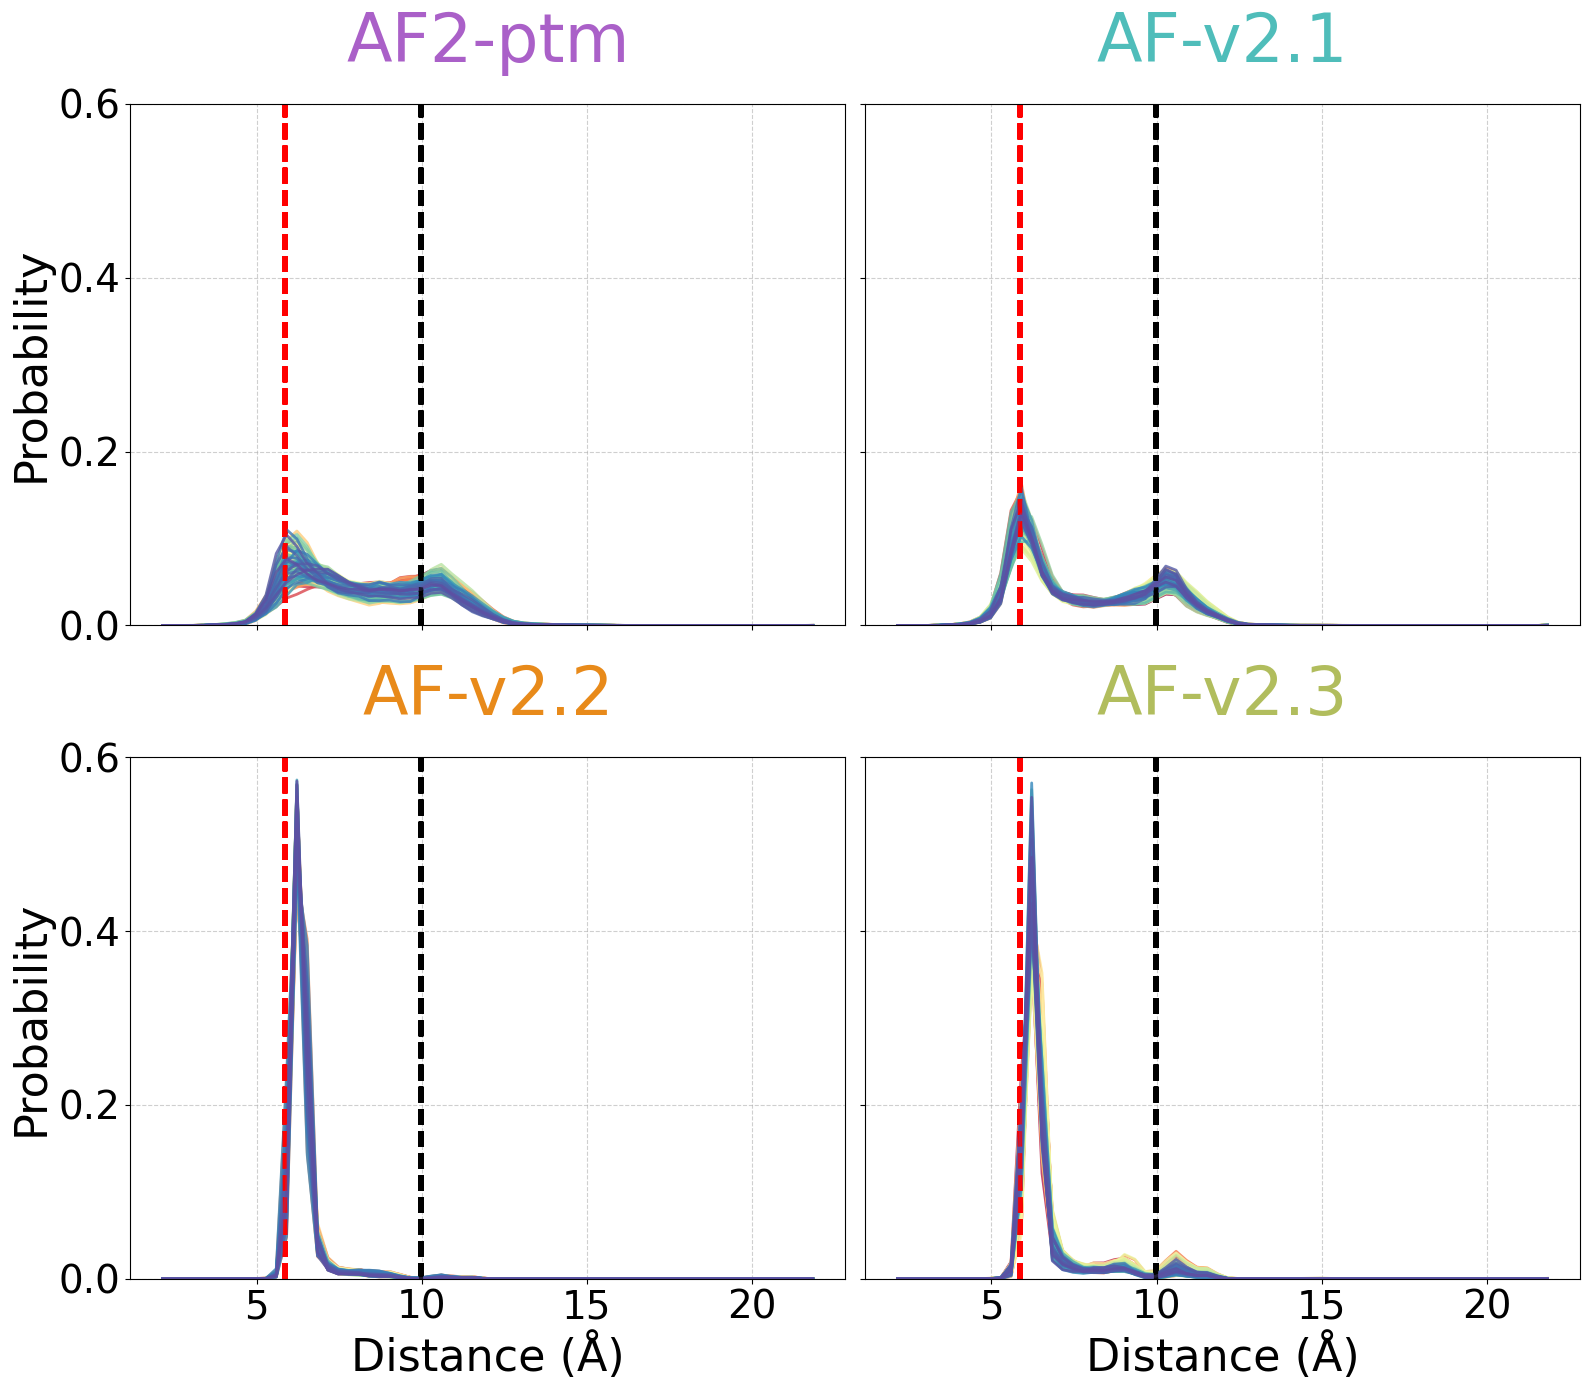

In [32]:
res_i = 230
res_j = 233
plot_all_distograms_by_version(
    "/Volumes/Expansion/FEBS/minniefold/ak2/distograms/",
    res_i=res_i,
    res_j=res_j,
    output_path="/Volumes/Expansion/FEBS/minniefold/ak2/distogram_versions_plot.png"
)

### AFsample2 distograms | Figure 2C

#### Raw data plotting

Plot saved to: /Volumes/Expansion/FEBS/afsample2/distogram_distribution_afsample2_ak2_res230_233.png


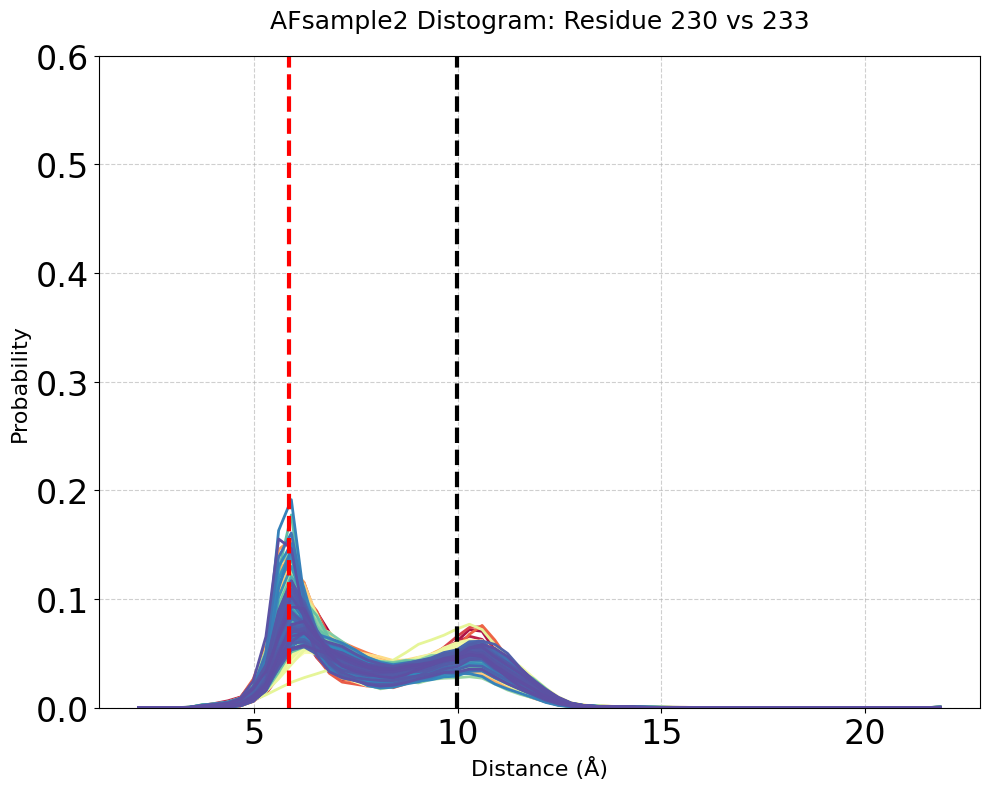

In [33]:
res_i = 230
res_j = 233
plot_all_distograms_in_directory(
    "/Volumes/Expansion/FEBS/afsample2/ak2/distograms",
    res_i=res_i,
    res_j=res_j,
    title=f"AFsample2 Distogram: Residue {res_i} vs {res_j}"
)

#### Highlighted plotting 

In [40]:
import os
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
import pickle
from matplotlib.ticker import FuncFormatter

def plot_all_distograms_in_directory_highlight(directory_path, res_i=230, res_j=233, temperature=1.0, title=None, output_filename=None, highlight_files=None):
    """
    Plot distograms for residue pair (res_i, res_j) from all .npz or .pkl files in a directory.
    Applies lower alpha/standard linewidth to background lines, and full alpha/increased linewidth
    to lines specified in highlight_files. The legend shows all labels with opaque, thick lines.

    Args:
        directory_path (str): Path to the folder containing distogram .npz or .pkl files.
        res_i (int): Residue index i (1-based biological indexing).
        res_j (int): Residue index j (1-based biological indexing).
        temperature (float): Temperature scaling for logits -> probability conversion.
        title (str, optional): Custom title for the plot. Defaults to a standard title.
        output_filename (str, optional): The filename for the saved plot (e.g., 'my_plot.png').
        highlight_files (list or None): List of *full* filenames (basenames + extension) to highlight.
    """
    file_paths = sorted(glob(os.path.join(directory_path, "*.npz")) + 
                        glob(os.path.join(directory_path, "*.pkl")) +
                        glob(os.path.join(directory_path, "*.pickle")))

    if not file_paths:
        print(f"No .npz, .pkl, or .pickle files found in {directory_path}")
        return

    # Define bin centers and edges for AlphaFold's 64-bin distogram
    bin_edges = np.arange(2.0, 22.0 + 0.3125, 0.3125)[:65]
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    plt.figure(figsize=(10, 8))
    
    all_lines = []
    all_labels = []
    
    # Line parameters 📐
    ALPHA_HIGHLIGHT = 1.0
    ALPHA_BACKGROUND = 0.0 
    LINEWIDTH_HIGHLIGHT = 3.5 
    LINEWIDTH_BACKGROUND = 1.5 
    
    # --- HIGHLIGHT LOGIC FIX ---
    # Correctly strip the extension from the highlight files before adding to the set
    highlight_set = set()
    if highlight_files:
        for fname in highlight_files:
            # Strip the extension (e.g., '.pickle') and convert to lowercase
            name_no_ext, _ = os.path.splitext(fname)
            highlight_set.add(name_no_ext.lower())
    
    # Print the expected highlight names for user debugging
    if highlight_set:
        print("--- Highlight Comparison Set (Lowercased, no extension) ---")
        for name in highlight_set:
            print(f"Target: {name}")
        print("----------------------------------------------------------")

    # Generate colors once for consistency
    colors = plt.cm.Spectral(np.linspace(0, 1, len(file_paths)))

    # Use separate lists to ensure highlighted lines are plotted LAST (on top)
    background_plot_data = []
    highlighted_plot_data = []

    for i, file_path in enumerate(file_paths):
        logits = None
        
        filename_full = os.path.basename(file_path)
        basename_no_ext, _ = os.path.splitext(filename_full)

        # The comparison now uses the correctly stripped name
        is_highlighted = basename_no_ext.lower() in highlight_set
        
        # --- File Loading Logic (streamlined) ---
        try:
            if file_path.endswith(".npz"):
                data = np.load(file_path, allow_pickle=True)
                logits = data.get('logits', None) or data.get('distogram', {}).get('logits', None)
                if logits is None and isinstance(data.get('distogram'), np.ndarray):
                    logits = data.get('distogram')
            elif file_path.endswith((".pkl", ".pickle")):
                with open(file_path, "rb") as f:
                    data = pickle.load(f)
                    logits = data.get('logits', None) or data.get('distogram', {}).get('logits', None)
                    if logits is None and isinstance(data.get('distogram'), np.ndarray):
                        logits = data.get('distogram')
        except Exception as e:
            print(f"Error loading {file_path}: {e}")
            continue

        # --- AMBIGUOUS TRUTH VALUE FIX ---
        # The 'logits is None' check handles the ambiguity for the first case.
        # However, if 'logits' is a NumPy array, a check like 'if not logits.any():' may be needed
        # if the array could be empty or all zeros. Since we expect a valid distogram array, 
        # checking the shape is more reliable.
        if logits is None or not isinstance(logits, np.ndarray) or logits.ndim < 3:
            # If data couldn't be loaded or isn't the expected format, skip.
            continue
        # ---------------------------------

        # Convert logits to probability using softmax
        scaled_logits = logits / temperature
        # Use np.max with keepdims=True to handle the broadcasting correctly
        exp_logits = np.exp(scaled_logits - np.max(scaled_logits, axis=-1, keepdims=True))
        probs = exp_logits / np.sum(exp_logits, axis=-1, keepdims=True)

        # Extract residue pair
        try:
            probs_res = probs[res_i - 1, res_j - 1, :]
        except IndexError:
            # print(f"Index error in {file_path}: shape={logits.shape}, requested=({res_i},{res_j}). Skipping.")
            continue

        plot_params = {
            'x': bin_centers,
            'y': probs_res,
            'label': basename_no_ext,
            'color': colors[i],
            'alpha': ALPHA_HIGHLIGHT if is_highlighted else ALPHA_BACKGROUND,
            'linewidth': LINEWIDTH_HIGHLIGHT if is_highlighted else LINEWIDTH_BACKGROUND
        }
        
        # Separate data for drawing order
        if is_highlighted:
            highlighted_plot_data.append(plot_params)
        else:
            background_plot_data.append(plot_params)

    # 1. Plot background lines first
    for params in background_plot_data:
        line, = plt.plot(params['x'], params['y'], label=params['label'], color=params['color'], 
                         linewidth=params['linewidth'], alpha=params['alpha'])
        all_lines.append(line)
        all_labels.append(params['label'])

    # 2. Plot highlighted lines last (on top)
    for params in highlighted_plot_data:
        line, = plt.plot(params['x'], params['y'], label=params['label'], color=params['color'], 
                         linewidth=params['linewidth'], alpha=params['alpha'])
        all_lines.append(line)
        all_labels.append(params['label'])


    ## --- Plot Customization ---
    if title is None:
        title = f"Distogram - Residue {res_i} vs {res_j}"
    
    plt.title(title, fontsize=18, pad=20)
    plt.xlabel("Distance (Å)", fontsize=18)
    plt.ylabel("Probability", fontsize=18)
    plt.ylim(0, 0.6)
    
    plt.xticks([5, 10, 15, 20], fontsize=24)
    plt.yticks(fontsize=24)
    
    # Example distance lines
    plt.axvline(x=5.86, color='red', linestyle='--', linewidth=3)
    plt.axvline(x=9.97, color='black', linestyle='--', linewidth=3)
    
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.1f}"))
    
    # Create the full legend with ALL labels
    #if all_lines:
        #leg = plt.legend(all_lines, all_labels, fontsize=8, loc="best", ncol=2, 
                #    title="Model Runs", title_fontsize=10, frameon=True)

        # Force legend handles to be fully opaque (alpha=1.0) and use the HIGHLIGHT linewidth
        #for line in leg.get_lines():
        #    line.set_alpha(1.0)
        #    line.set_linewidth(LINEWIDTH_HIGHLIGHT)
            
    plt.tight_layout()

    ## --- Output Filename Logic ---
    if output_filename:
        output_dir = os.path.dirname(os.path.dirname(directory_path))
        if not output_dir:
            output_dir = "."
        final_output_path = os.path.join(output_dir, output_filename + ".png")
    else:
        # Default filename generation
        base_dir = os.path.dirname(directory_path)
        grandparent = os.path.basename(os.path.dirname(base_dir))
        target = os.path.basename(base_dir)
        default_filename = f"distogram_distribution_{grandparent}_{target}_res{res_i}_{res_j}.png"
        final_output_path = os.path.join(os.path.dirname(base_dir), default_filename)

    ## --- Save Plot ---
    plt.savefig(final_output_path, dpi=300)
    print(f"Plot saved to: {final_output_path}")
    
    plt.show()

--- Highlight Comparison Set (Lowercased, no extension) ---
Target: result_model_3_ptm_pred_9_nodropout
Target: result_model_2_ptm_pred_27_nodropout
Target: result_model_5_ptm_pred_12_nodropout
----------------------------------------------------------
Plot saved to: /Volumes/Expansion/FEBS/afsample2/ak2/distogram_distribution_ak2_distograms_res230_233.png


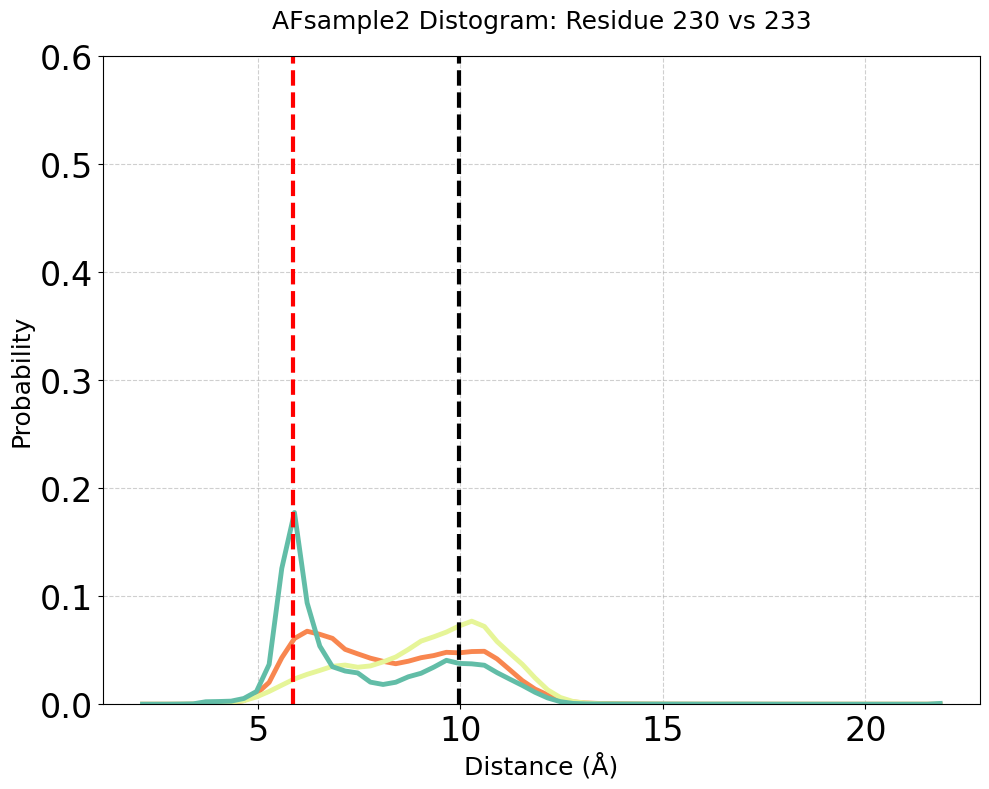

In [46]:
res_i = 230
res_j = 233
plot_all_distograms_in_directory_highlight(
    "/Volumes/Expansion/FEBS/afsample2/ak2/distograms/",
    res_i=res_i,
    res_j=res_j,
    title=f"AFsample2 Distogram: Residue {res_i} vs {res_j}",
    highlight_files=["result_model_3_ptm_pred_9_nodropout.pkl", "result_model_2_ptm_pred_27_nodropout.pkl", "result_model_5_ptm_pred_12_nodropout.pkl"]
)

#### Highlighted plotting, close-up view

--- Highlight Comparison Set (Lowercased, no extension) ---
Target: result_model_3_ptm_pred_9_nodropout
Target: result_model_2_ptm_pred_27_nodropout
Target: result_model_5_ptm_pred_12_nodropout
----------------------------------------------------------
Plot saved to: /Volumes/Expansion/FEBS/afsample2/ak2/distogram_distribution_ak2_distograms_res230_233.png


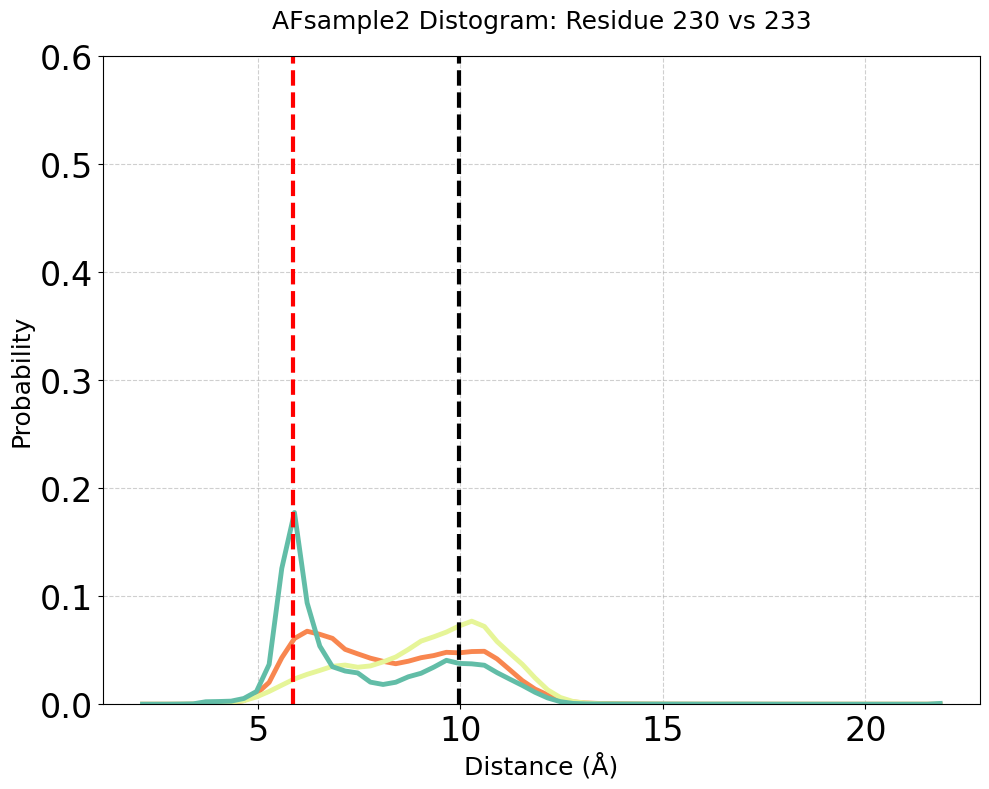

In [41]:
res_i = 230
res_j = 233
plot_all_distograms_in_directory_highlight(
    "/Volumes/Expansion/FEBS/afsample2/ak2/distograms/",
    res_i=res_i,
    res_j=res_j,
    title=f"AFsample2 Distogram: Residue {res_i} vs {res_j}",
    highlight_files=["result_model_3_ptm_pred_9_nodropout.pkl", "result_model_2_ptm_pred_27_nodropout.pkl", "result_model_5_ptm_pred_12_nodropout.pkl"]
)

### AF_cluster distograms | Figure 2C

#### Raw data plotting 

Plot saved to: /Volumes/Expansion/FEBS/af_cluster/distogram_distribution_af_cluster_ak2_res230_233.png


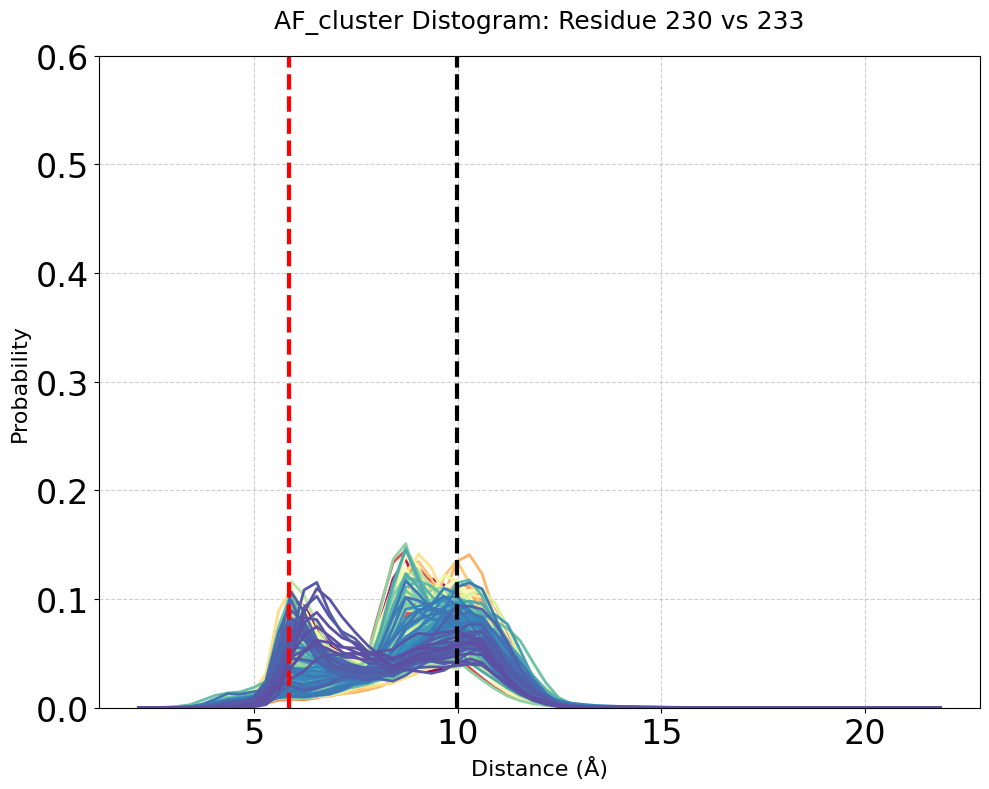

In [37]:
res_i = 230
res_j = 233
plot_all_distograms_in_directory(
    "/Volumes/Expansion/FEBS/af_cluster/ak2/distograms",
    res_i=res_i,
    res_j=res_j,
    title=f"AF_cluster Distogram: Residue {res_i} vs {res_j}"
)

#### Highlighted plotting

--- Highlight Comparison Set (Lowercased, no extension) ---
Target: ak2-clustered__ak2_214.a3m_0_all_rank_001_alphafold2_ptm_model_1_seed_000
Target: ak2-clustered__ak2_374.a3m_0_all_rank_001_alphafold2_ptm_model_1_seed_000
Target: ak2-clustered__ak2_296.a3m_0_all_rank_001_alphafold2_ptm_model_1_seed_000
Target: ak2-clustered__ak2_016.a3m_0_all_rank_001_alphafold2_ptm_model_1_seed_000
----------------------------------------------------------
Plot saved to: /Volumes/Expansion/FEBS/af_cluster/distogram_distribution_af_cluster_ak2_res230_233.png


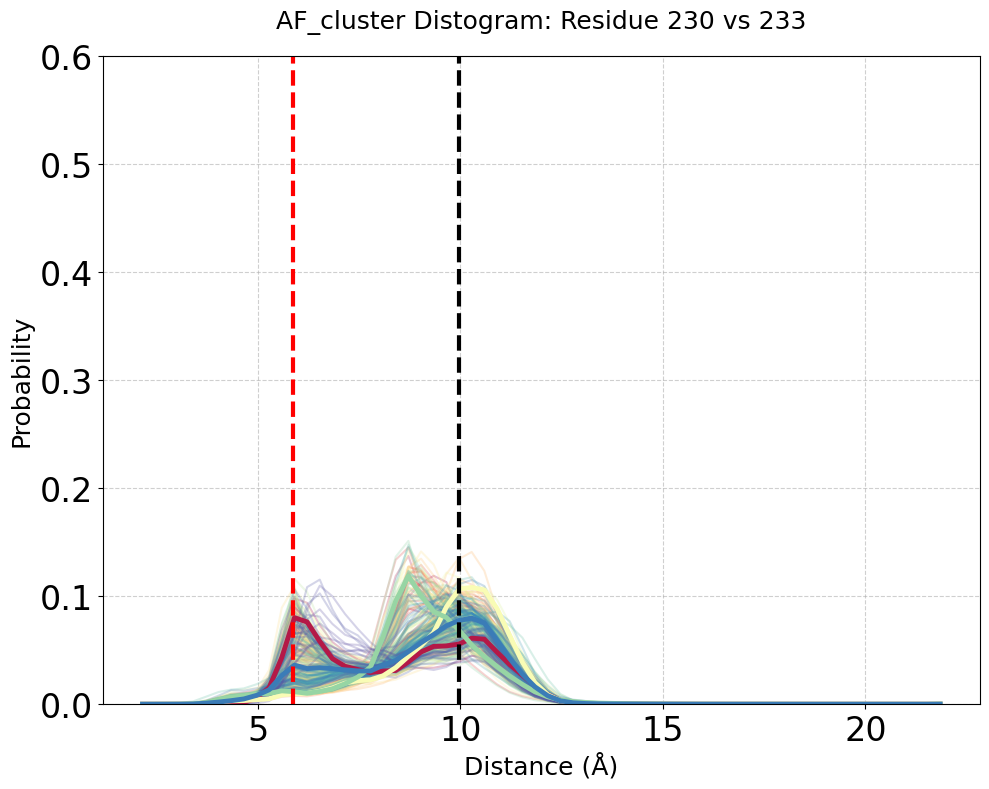

In [39]:
res_i = 230
res_j = 233
plot_all_distograms_in_directory_highlight(
    "/Volumes/Expansion/FEBS/af_cluster/ak2/distograms",
    res_i=res_i,
    res_j=res_j,
    title=f"AF_cluster Distogram: Residue {res_i} vs {res_j}",
    highlight_files=["ak2-clustered__ak2_016.a3m_0_all_rank_001_alphafold2_ptm_model_1_seed_000.pickle","ak2-clustered__ak2_214.a3m_0_all_rank_001_alphafold2_ptm_model_1_seed_000.pickle","ak2-clustered__ak2_296.a3m_0_all_rank_001_alphafold2_ptm_model_1_seed_000.pickle","ak2-clustered__ak2_374.a3m_0_all_rank_001_alphafold2_ptm_model_1_seed_000.pickle"]
)

#### Highlighted plotting, close-up view

--- Highlight Comparison Set (Lowercased, no extension) ---
Target: ak2-clustered__ak2_214.a3m_0_all_rank_001_alphafold2_ptm_model_1_seed_000
Target: ak2-clustered__ak2_374.a3m_0_all_rank_001_alphafold2_ptm_model_1_seed_000
Target: ak2-clustered__ak2_296.a3m_0_all_rank_001_alphafold2_ptm_model_1_seed_000
Target: ak2-clustered__ak2_016.a3m_0_all_rank_001_alphafold2_ptm_model_1_seed_000
----------------------------------------------------------
Plot saved to: /Volumes/Expansion/FEBS/af_cluster/distogram_distribution_af_cluster_ak2_res230_233.png


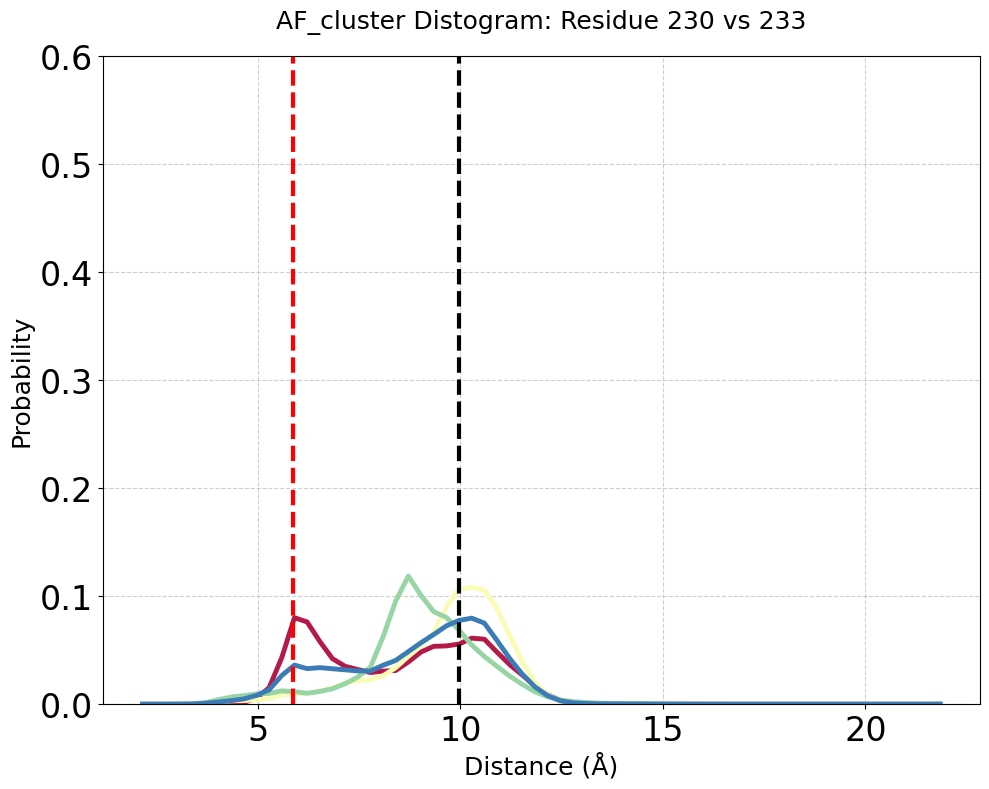

In [45]:
res_i = 230
res_j = 233
plot_all_distograms_in_directory_highlight(
    "/Volumes/Expansion/FEBS/af_cluster/ak2/distograms",
    res_i=res_i,
    res_j=res_j,
    title=f"AF_cluster Distogram: Residue {res_i} vs {res_j}",
    highlight_files=["ak2-clustered__ak2_016.a3m_0_all_rank_001_alphafold2_ptm_model_1_seed_000.pickle","ak2-clustered__ak2_214.a3m_0_all_rank_001_alphafold2_ptm_model_1_seed_000.pickle","ak2-clustered__ak2_296.a3m_0_all_rank_001_alphafold2_ptm_model_1_seed_000.pickle","ak2-clustered__ak2_374.a3m_0_all_rank_001_alphafold2_ptm_model_1_seed_000.pickle"]
)

### AF3sample2 distograms | Figure 2D

Plot saved to: /Volumes/Expansion/FEBS/af3sample2/distogram_distribution_af3sample2_ak2_res230_233.png


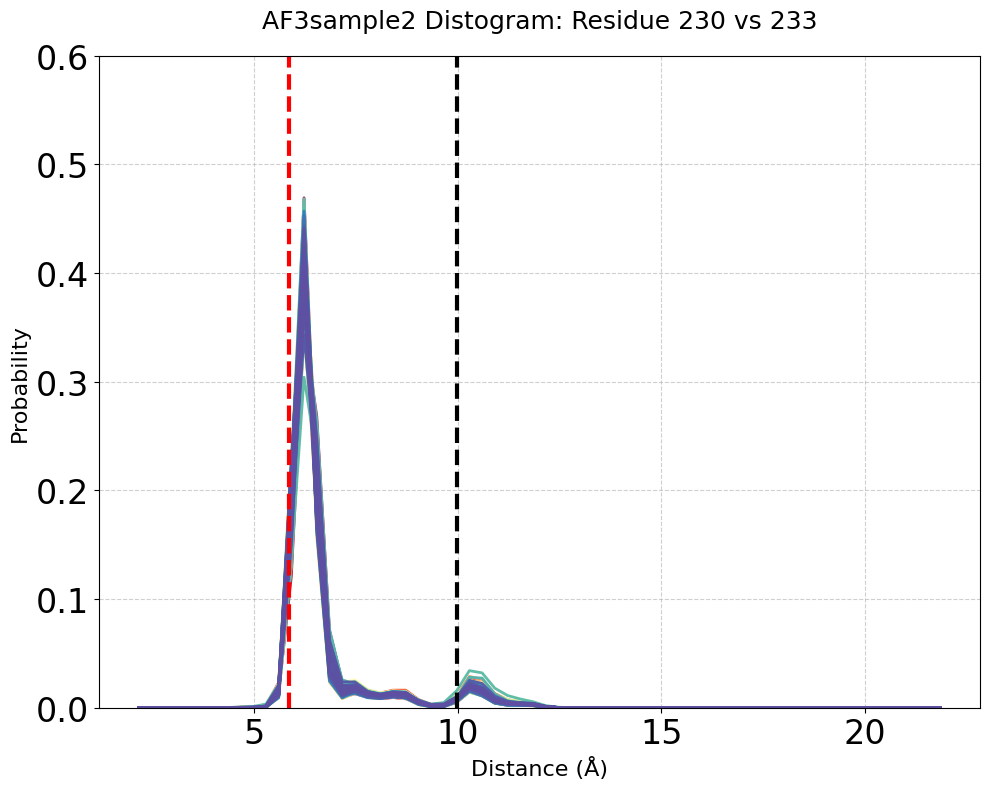

In [47]:
res_i = 230
res_j = 233
plot_all_distograms_in_directory(
    "/Volumes/Expansion/FEBS/af3sample2/ak2/distograms",
    res_i=res_i,
    res_j=res_j,
    title=f"AF3sample2 Distogram: Residue {res_i} vs {res_j}"
)

### AF3_cluster distograms | Figure 2D

#### Raw data plotting 

Plot saved to: /Volumes/Expansion/FEBS/af3_cluster/distogram_distribution_af3_cluster_ak2_res230_233.png


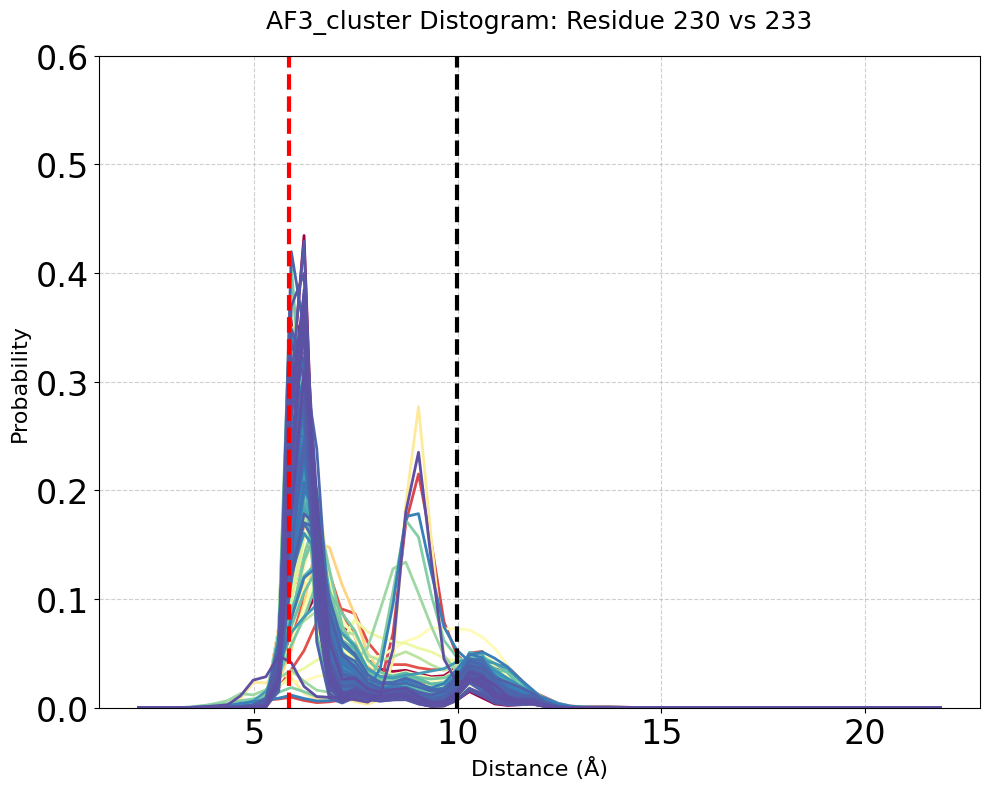

In [48]:
res_i = 230
res_j = 233
plot_all_distograms_in_directory(
    "/Volumes/Expansion/FEBS/af3_cluster/ak2/distograms",
    res_i=res_i,
    res_j=res_j,
    title=f"AF3_cluster Distogram: Residue {res_i} vs {res_j}"
)

#### Highlighted plotting 

In [52]:
import os
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
import pickle
from matplotlib.ticker import FuncFormatter

def plot_all_distograms_in_directory_highlight(directory_path, res_i=230, res_j=233, temperature=1.0, title=None, output_filename=None, highlight_files=None):
    """
    Plot distograms for residue pair (res_i, res_j) from all .npz or .pkl files in a directory.
    Applies lower alpha/standard linewidth to background lines, and full alpha/increased linewidth
    to lines specified in highlight_files.

    Args:
        directory_path (str): Path to the folder containing distogram .npz or .pkl files.
        res_i (int): Residue index i (1-based biological indexing).
        res_j (int): Residue index j (1-based biological indexing).
        temperature (float): Temperature scaling for logits -> probability conversion.
        title (str, optional): Custom title for the plot. Defaults to a standard title.
        output_filename (str, optional): The filename for the saved plot (e.g., 'my_plot.png').
        highlight_files (list or None): List of *full* filenames (basenames + extension) to highlight.
    """
    file_paths = sorted(glob(os.path.join(directory_path, "*.npz")) + 
                        glob(os.path.join(directory_path, "*.pkl")) +
                        glob(os.path.join(directory_path, "*.pickle")))

    if not file_paths:
        print(f"No .npz, .pkl, or .pickle files found in {directory_path}")
        return

    # Define bin centers and edges for AlphaFold's 64-bin distogram
    bin_edges = np.arange(2.0, 22.0 + 0.3125, 0.3125)[:65] # Corrected bin end from your working code
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    plt.figure(figsize=(10, 8))
    
    all_lines = []
    all_labels = []
    
    # Line parameters 📐
    ALPHA_HIGHLIGHT = 1.0
    ALPHA_BACKGROUND = 0.0
    LINEWIDTH_HIGHLIGHT = 3.5 
    LINEWIDTH_BACKGROUND = 1.5 
    
    # --- HIGHLIGHT LOGIC ---
    highlight_set = set()
    if highlight_files:
        for fname in highlight_files:
            # Strip the extension (e.g., '.pickle') and convert to lowercase
            name_no_ext, _ = os.path.splitext(fname)
            highlight_set.add(name_no_ext.lower())
    
    if highlight_set:
        print("--- Highlight Comparison Set (Lowercased, no extension) ---")
        for name in highlight_set:
            print(f"Target: {name}")
        print("----------------------------------------------------------")

    # Generate colors once for consistency
    colors = plt.cm.Spectral(np.linspace(0, 1, len(file_paths)))

    # Use separate lists to ensure highlighted lines are plotted LAST (on top)
    background_plot_data = []
    highlighted_plot_data = []

    for i, file_path in enumerate(file_paths):
        logits = None
        
        filename_full = os.path.basename(file_path)
        basename_no_ext, _ = os.path.splitext(filename_full)
        is_highlighted = basename_no_ext.lower() in highlight_set
        
        # --- File Loading Logic (Based on your working code) ---
        try:
            if file_path.endswith(".npz"):
                data = np.load(file_path, allow_pickle=True)
                
                # If it's a raw array (the source of the original error), use it directly
                if isinstance(data, np.ndarray):
                    logits = data
                # If it's the NpzFile dictionary-like object:
                elif hasattr(data, 'get'): 
                    logits = data.get('logits', None)
                    if logits is None:
                        dgram = data.get('distogram', None)
                        if isinstance(dgram, dict) and 'logits' in dgram:
                            logits = dgram['logits']
                        # CRITICAL: Handle the case where 'distogram' key holds the array directly
                        elif isinstance(dgram, np.ndarray):
                            logits = dgram
                        # Fallback for 'arr_0' if single un-named array was saved
                        elif 'arr_0' in data:
                            logits = data['arr_0']
            
            elif file_path.endswith((".pkl", ".pickle")):
                with open(file_path, "rb") as f:
                    data = pickle.load(f)
                    if 'logits' in data:
                        logits = data['logits']
                    elif 'distogram' in data:
                        dgram = data['distogram']
                        if isinstance(dgram, dict) and 'logits' in dgram:
                            logits = dgram['logits']
                        elif isinstance(dgram, np.ndarray):
                            logits = dgram
                            
        except Exception as e:
            print(f"Error loading {file_path}: {e}")
            continue

        # --- VALIDATION ---
        if logits is None or not isinstance(logits, np.ndarray) or logits.ndim < 3 or logits.shape[-1] != 64:
            # print(f"Skipping {filename_full}. Shape or content invalid: {logits.shape if isinstance(logits, np.ndarray) else 'None'}")
            continue
        # ------------------

        # Convert logits to probability using softmax
        scaled_logits = logits / temperature
        exp_logits = np.exp(scaled_logits - np.max(scaled_logits, axis=-1, keepdims=True))
        probs = exp_logits / np.sum(exp_logits, axis=-1, keepdims=True)

        # Extract residue pair
        try:
            probs_res = probs[res_i - 1, res_j - 1, :]
        except IndexError:
            print(f"Index error in {filename_full}: shape={logits.shape}, requested=({res_i},{res_j}). Skipping.")
            continue

        plot_params = {
            'x': bin_centers,
            'y': probs_res,
            'label': basename_no_ext,
            'color': colors[i],
            'alpha': ALPHA_HIGHLIGHT if is_highlighted else ALPHA_BACKGROUND,
            'linewidth': LINEWIDTH_HIGHLIGHT if is_highlighted else LINEWIDTH_BACKGROUND
        }
        
        # Separate data for drawing order
        if is_highlighted:
            highlighted_plot_data.append(plot_params)
        else:
            background_plot_data.append(plot_params)

    # 1. Plot background lines first
    for params in background_plot_data:
        line, = plt.plot(params['x'], params['y'], label=params['label'], color=params['color'], 
                         linewidth=params['linewidth'], alpha=params['alpha'])
        all_lines.append(line)
        all_labels.append(params['label'])

    # 2. Plot highlighted lines last (on top)
    for params in highlighted_plot_data:
        line, = plt.plot(params['x'], params['y'], label=params['label'], color=params['color'], 
                         linewidth=params['linewidth'], alpha=params['alpha'])
        all_lines.append(line)
        all_labels.append(params['label'])


    ## --- Plot Customization ---
    if title is None:
        title = f"Distogram - Residue {res_i} vs {res_j}"
    
    plt.title(title, fontsize=18, pad=20)
    plt.xlabel("Distance (Å)", fontsize=18)
    plt.ylabel("Probability", fontsize=18)
    plt.ylim(0, 0.6)
    
    plt.xticks([5, 10, 15, 20], fontsize=24)
    plt.yticks(fontsize=24)
    
    # Example distance lines
    plt.axvline(x=5.86, color='red', linestyle='--', linewidth=3)
    plt.axvline(x=9.97, color='black', linestyle='--', linewidth=3)
    
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.1f}"))
    
    # Create the full legend with ALL labels
    #if all_lines:
    #    leg = plt.legend(all_lines, all_labels, fontsize=8, loc="best", ncol=2, 
    #                     title="Model Runs", title_fontsize=10, frameon=True)

        # Force legend handles to be fully opaque (alpha=1.0) and use the HIGHLIGHT linewidth
     #   for line in leg.get_lines():
     #       line.set_alpha(1.0)
     #       line.set_linewidth(LINEWIDTH_HIGHLIGHT)
            
    plt.tight_layout()

    ## --- Output Filename Logic ---
    if output_filename:
        output_dir = os.path.dirname(os.path.dirname(directory_path))
        if not output_dir:
            output_dir = "."
        final_output_path = os.path.join(output_dir, output_filename + ".png")
    else:
        # Default filename generation
        base_dir = os.path.dirname(directory_path)
        grandparent = os.path.basename(os.path.dirname(base_dir))
        target = os.path.basename(base_dir)
        default_filename = f"distogram_distribution_{grandparent}_{target}_res{res_i}_{res_j}.png"
        final_output_path = os.path.join(os.path.dirname(base_dir), default_filename)

    ## --- Save Plot ---
    plt.savefig(final_output_path, dpi=300)
    print(f"Plot saved to: {final_output_path}")
    
    plt.show()

--- Highlight Comparison Set (Lowercased, no extension) ---
Target: aa
Target: zzz
Target: ak2-clustered-ak2_345_seed-0_distogram
Target: ak2-clustered-ak2_34aa
----------------------------------------------------------
Plot saved to: /Volumes/Expansion/FEBS/af3_cluster/ak2/distogram_distribution_ak2_distograms_res230_233.png


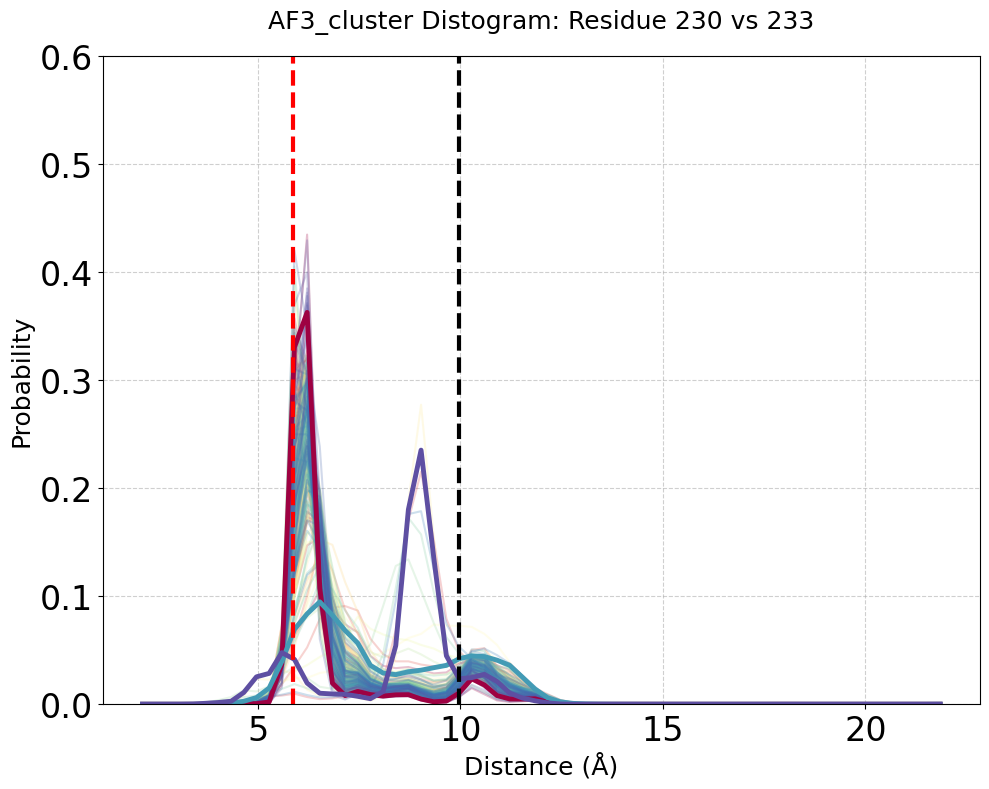

In [51]:
res_i = 230
res_j = 233
plot_all_distograms_in_directory_highlight(
    "/Volumes/Expansion/FEBS/af3_cluster/ak2/distograms/",
    res_i=res_i,
    res_j=res_j,
    title=f"AF3_cluster Distogram: Residue {res_i} vs {res_j}",
    highlight_files=["aa.npz", "ak2-clustered-ak2_34aa.npz", "zzz.npz", "ak2-clustered-ak2_345_seed-0_distogram.npz"]
)

#### Highlighted plotting, close-up view

--- Highlight Comparison Set (Lowercased, no extension) ---
Target: aa
Target: zzz
Target: ak2-clustered-ak2_345_seed-0_distogram
Target: ak2-clustered-ak2_34aa
----------------------------------------------------------
Plot saved to: /Volumes/Expansion/FEBS/af3_cluster/ak2/distogram_distribution_ak2_distograms_res230_233.png


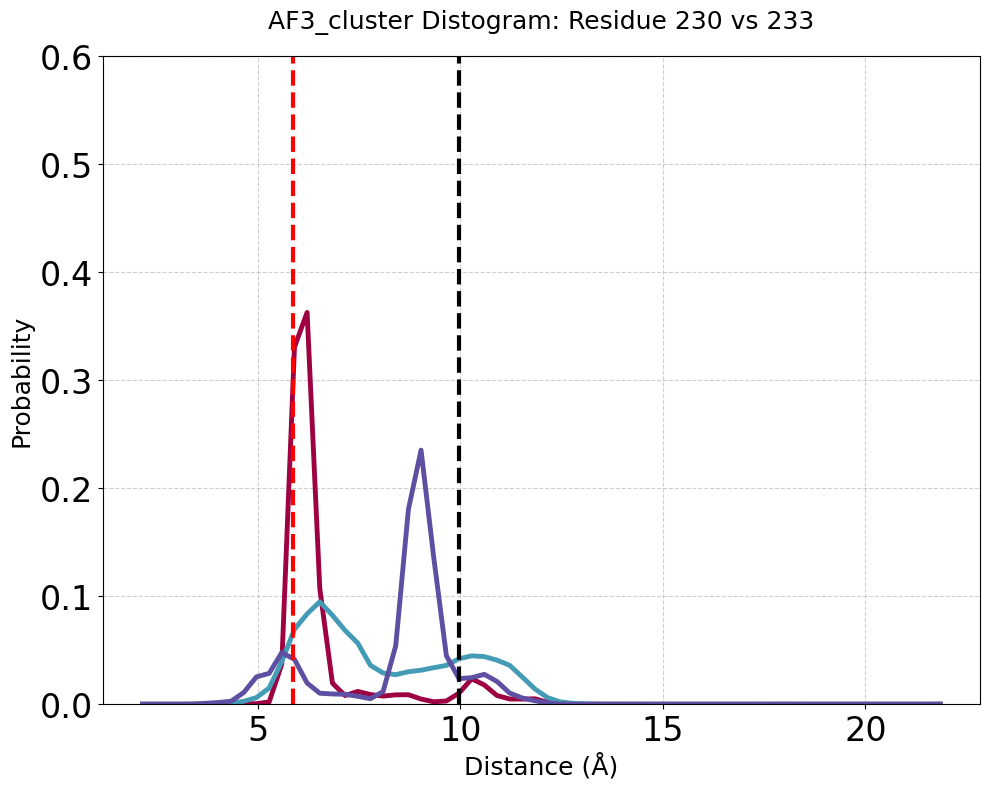

In [53]:
res_i = 230
res_j = 233
plot_all_distograms_in_directory_highlight(
    "/Volumes/Expansion/FEBS/af3_cluster/ak2/distograms/",
    res_i=res_i,
    res_j=res_j,
    title=f"AF3_cluster Distogram: Residue {res_i} vs {res_j}",
    highlight_files=["aa.npz", "ak2-clustered-ak2_34aa.npz", "zzz.npz", "ak2-clustered-ak2_345_seed-0_distogram.npz"]
)

# Ensemble based distance distribution | Figure 3

## AF2 based

### MinnieFold

Mean distance: 6.26 Å
Median distance: 6.22 Å


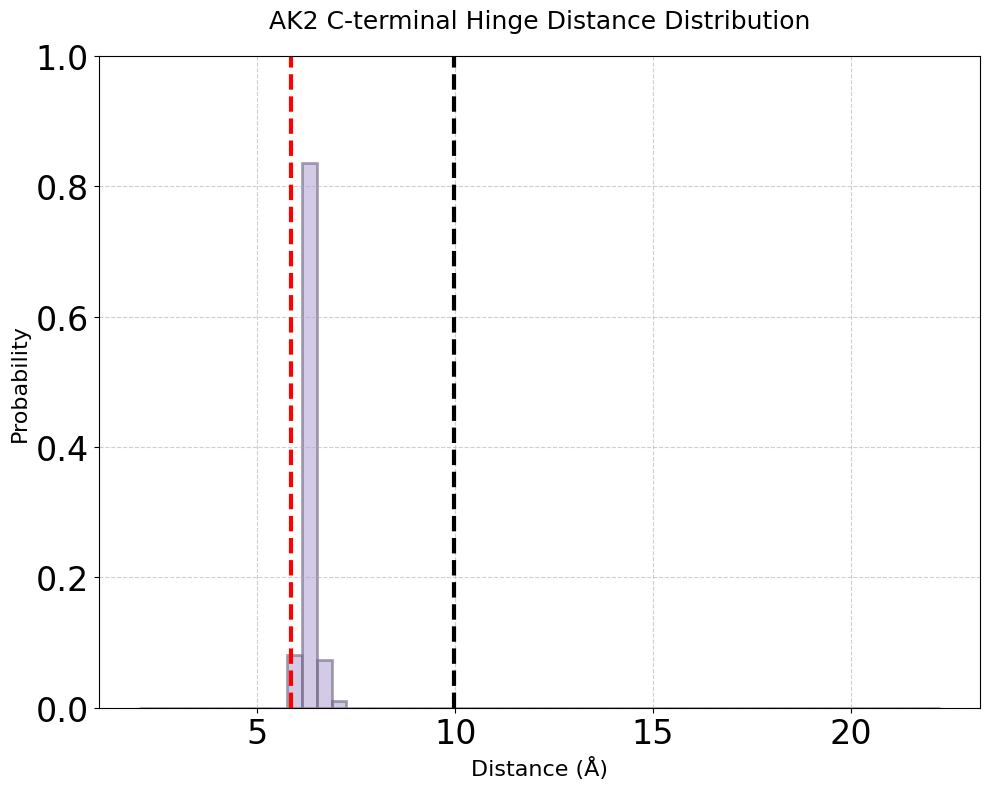

In [54]:
plot_distance_normalized_frequency(
    csv_file="/Volumes/Expansion/FEBS/minniefold/ak2/measurements.csv",
    title="AK2 C-terminal Hinge Distance Distribution",
    color="#B6A8D6",
    edgecolor="#6D6481",
    output_filename="Minniefold-distance"
)

### AFsample2

Mean distance: 6.31 Å
Median distance: 6.32 Å


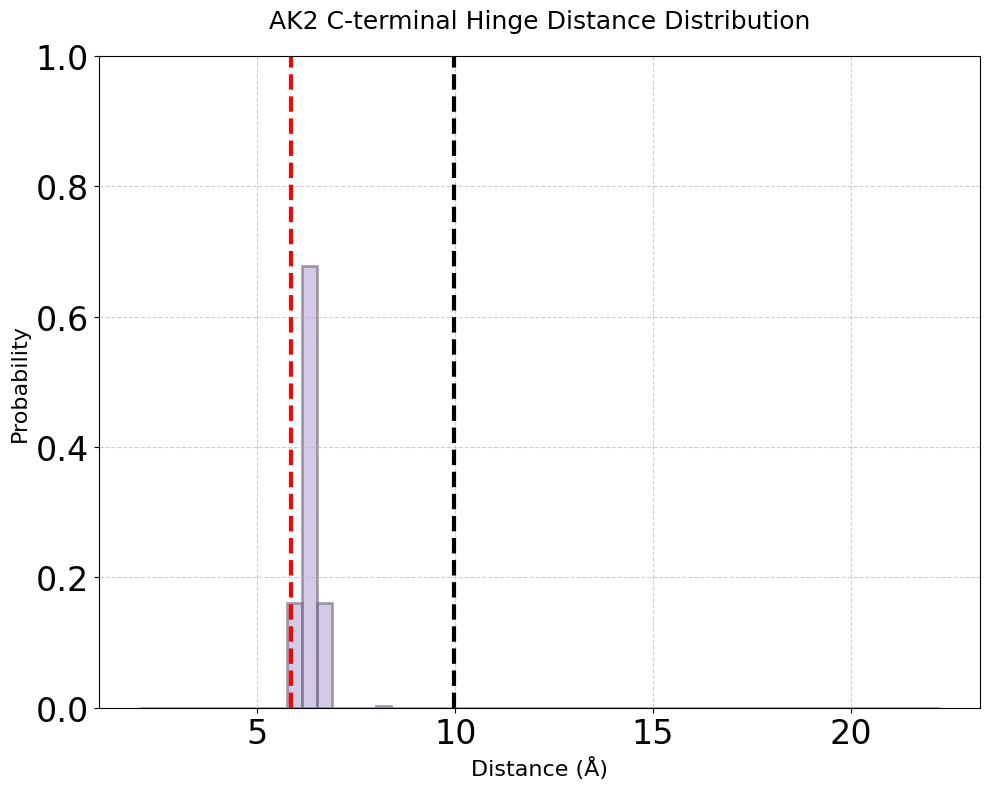

In [55]:
plot_distance_normalized_frequency(
    csv_file="/Volumes/Expansion/FEBS/afsample2/ak2/measurements.csv",
    title="AK2 C-terminal Hinge Distance Distribution",
    color="#B6A8D6",
    edgecolor="#6D6481",
    output_filename="AF2sample2-distance"
)

### AF_cluster

Mean distance: 8.02 Å
Median distance: 7.65 Å


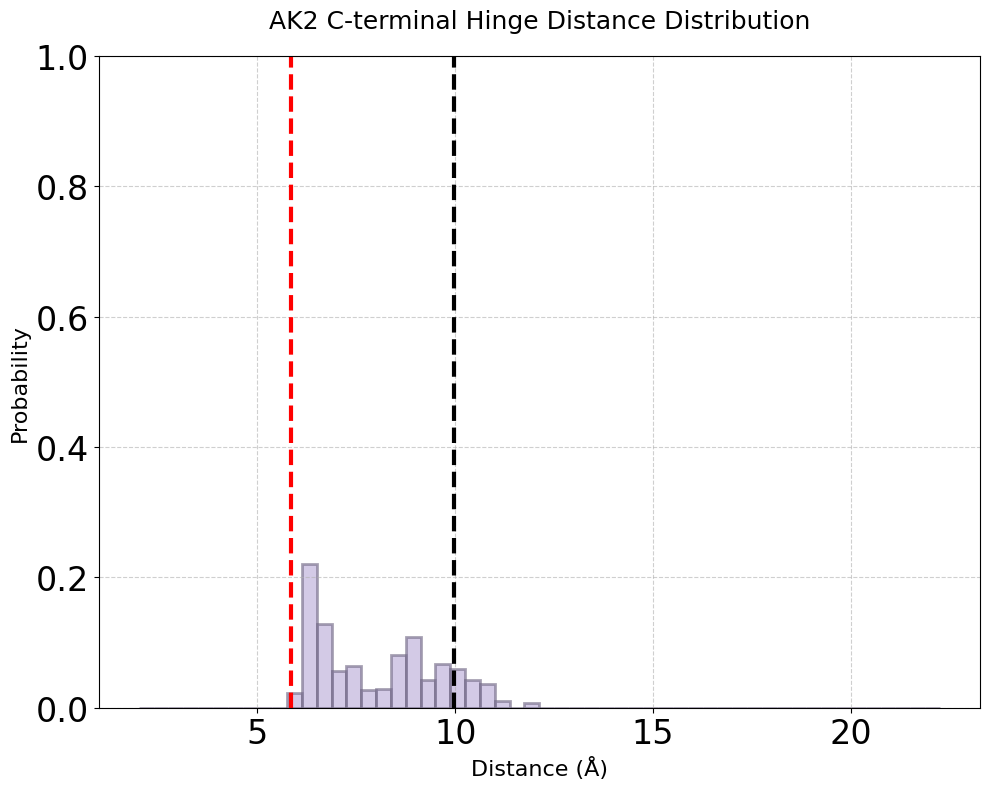

In [56]:
plot_distance_normalized_frequency(
    csv_file="/Volumes/Expansion/FEBS/af_cluster/ak2/measurements.csv",
    title="AK2 C-terminal Hinge Distance Distribution",
    color="#B6A8D6",
    edgecolor="#6D6481",
    output_filename="AF2_cluster-distance"
)

## AF3 based

### AF3 (multi seeds)

Mean distance: 6.28 Å
Median distance: 6.27 Å


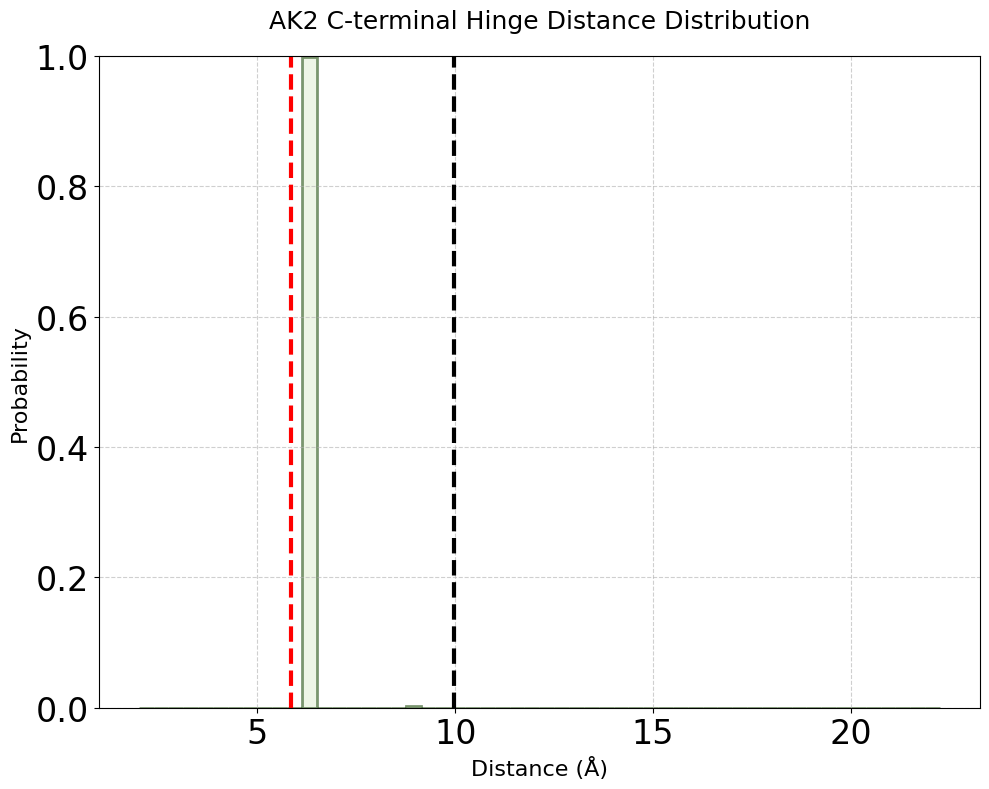

In [58]:
plot_distance_normalized_frequency(
    csv_file="/Volumes/Expansion/FEBS/af3/ak2/multi-seeds/measurements.csv",
    title="AK2 C-terminal Hinge Distance Distribution",
    color="#E3EFD6",
    edgecolor="#275317",
    output_filename="AF3-multiple-seed-distance"
)

### AF3sample2

Mean distance: 6.31 Å
Median distance: 6.27 Å


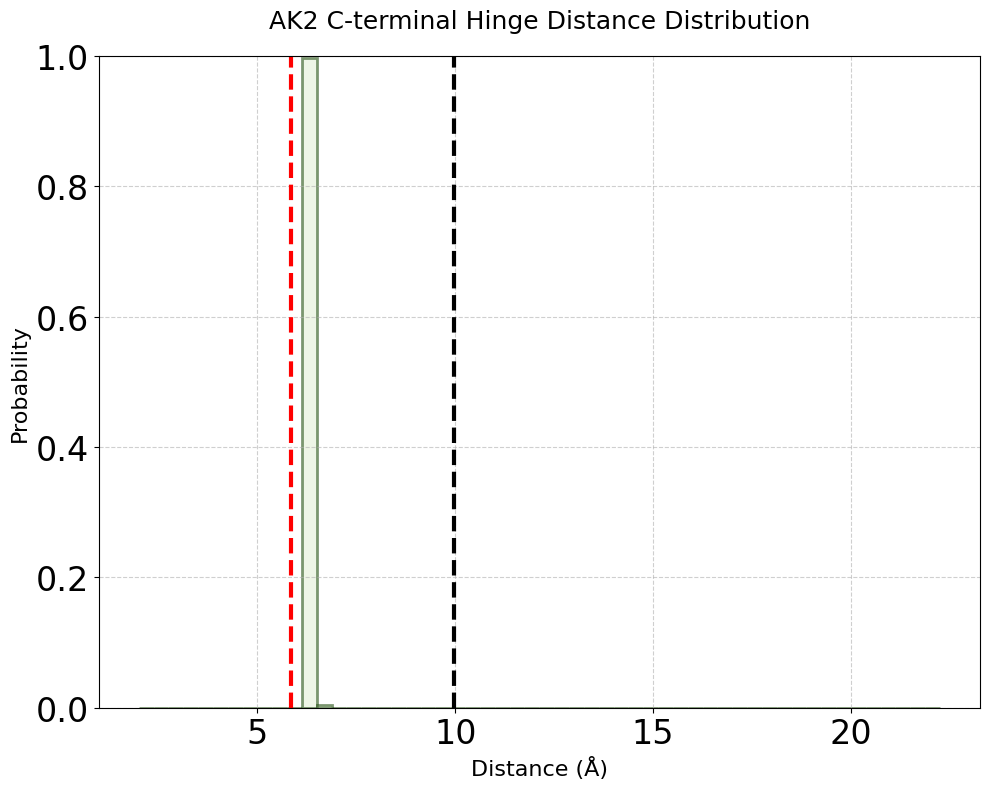

In [59]:
plot_distance_normalized_frequency(
    csv_file="/Volumes/Expansion/FEBS/af3sample2/ak2/measurements.csv",
    title="AK2 C-terminal Hinge Distance Distribution",
    color="#E3EFD6",
    edgecolor="#275317",
    output_filename="AF3sample2-seed-distance"
)

### AF3_cluster

Mean distance: 6.25 Å
Median distance: 6.20 Å


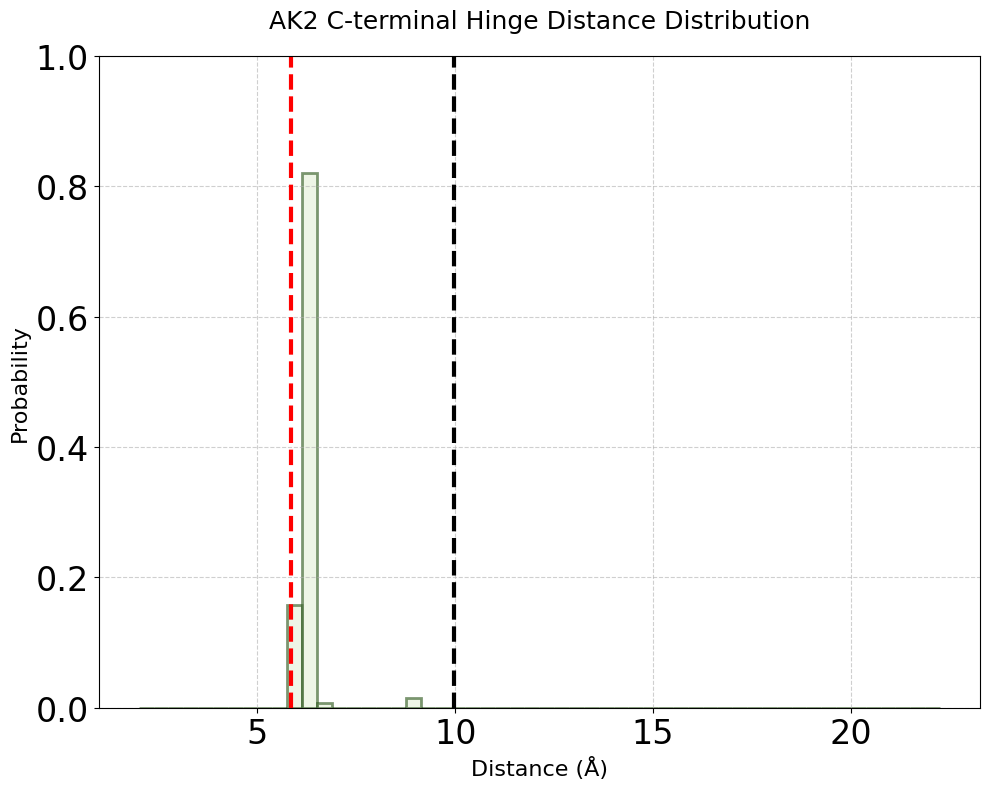

In [60]:
plot_distance_normalized_frequency(
    csv_file="/Volumes/Expansion/FEBS/af3_cluster/ak2/measurements.csv",
    title="AK2 C-terminal Hinge Distance Distribution",
    color="#E3EFD6",
    edgecolor="#275317",
    output_filename="AF3_cluster-seed-distance"
)

## Generative

### BioEmu

Mean distance: 7.76 Å
Median distance: 6.91 Å


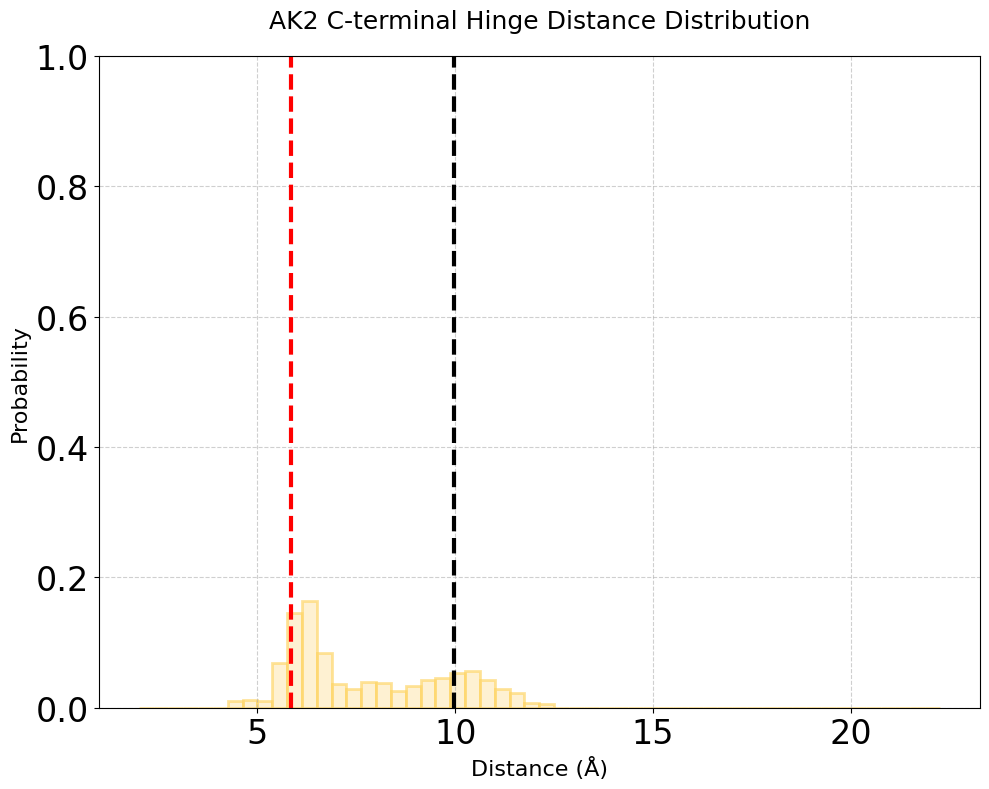

In [61]:
plot_distance_normalized_frequency(
    csv_file="/Volumes/Expansion/FEBS/bioemu/ak2/measurements.csv",
    title="AK2 C-terminal Hinge Distance Distribution",
    color="#FEE8B5",
    edgecolor="#FED259",
    output_filename="BioEmu-distance"
)

### Chai-1

Mean distance: 5.90 Å
Median distance: 5.79 Å


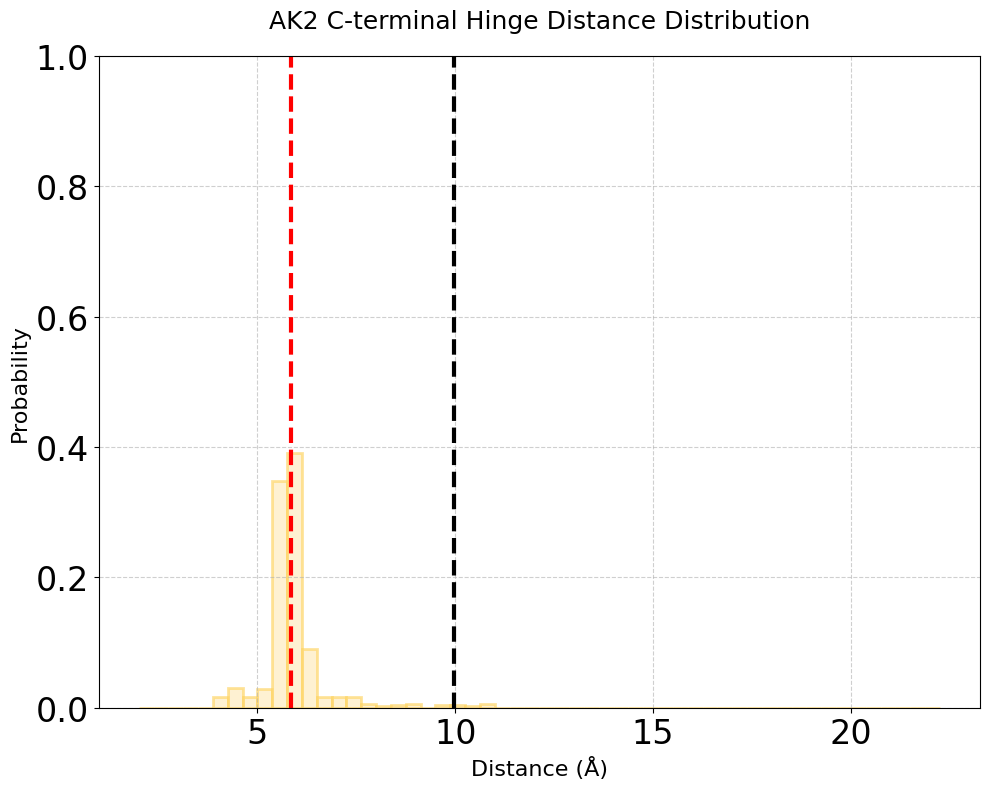

In [62]:
plot_distance_normalized_frequency(
    csv_file="/Volumes/Expansion/FEBS/chai/ak2/measurements.csv",
    title="AK2 C-terminal Hinge Distance Distribution",
    color="#FEE8B5",
    edgecolor="#FED259",
    output_filename="Chai1-distance"
)

### Boltz-2

Mean distance: 7.08 Å
Median distance: 6.10 Å


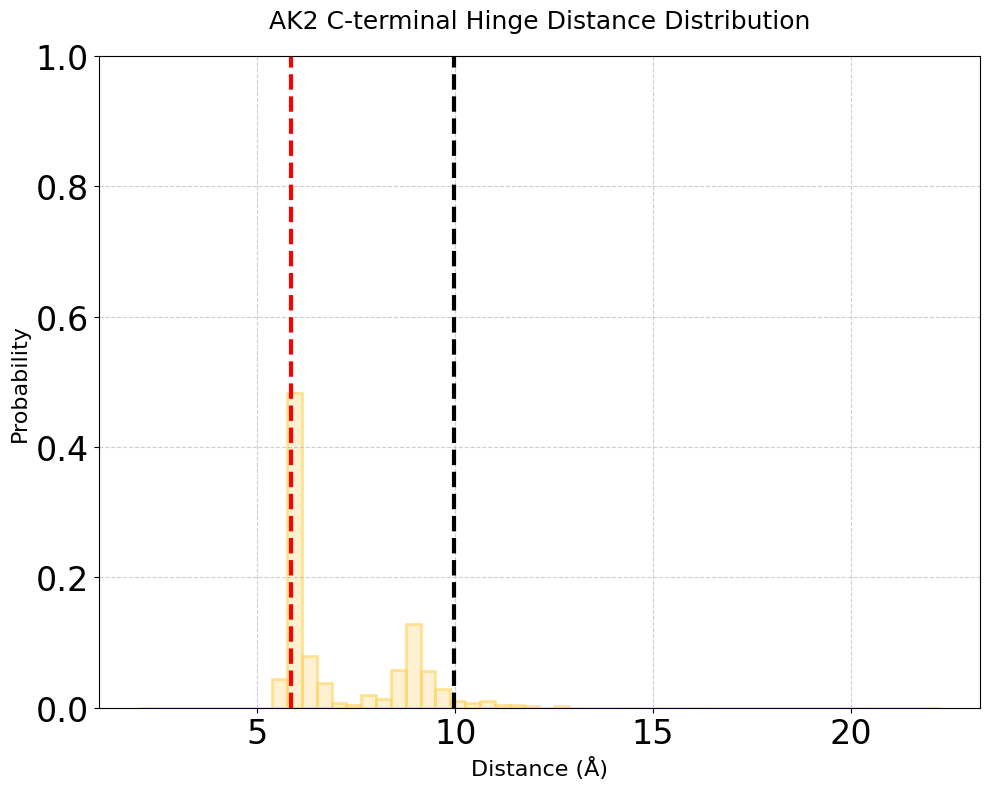

In [63]:
plot_distance_normalized_frequency(
    csv_file="/Volumes/Expansion/FEBS/boltz-2/ak2/measurements.csv",
    title="AK2 C-terminal Hinge Distance Distribution",
    color="#FEE8B5",
    edgecolor="#FED259",
    output_filename="Boltz-2-distance"
)

# Conformational flexibility across distinct structural contexts | Figure 4

In [64]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pickle

def plot_distogram_for_a_residue(pickle_path, residue_of_interest, cols=20, save_fig=False, fig_name=None):
    # Load pickle file
    with open(pickle_path, 'rb') as file:
        data = pickle.load(file)

    logits = data['distogram']['logits']

    # Convert logits to probabilities
    temperature = 1.0
    scaled_logits = logits / temperature
    exp_logits = np.exp(scaled_logits - np.max(scaled_logits, axis=-1, keepdims=True))
    probs = exp_logits / np.sum(exp_logits, axis=-1, keepdims=True)

    num_residues = logits.shape[0]
    bin_edges = np.arange(2.0, 22.1875 + 0.3125, 0.3125)[:65]
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    rows = int(np.ceil(num_residues / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    axes = axes.flatten()

    colors = (['#725CAD'] * num_residues)

    for idx, ax in enumerate(axes):
        if idx < num_residues and (residue_of_interest - 1) != idx:
            ax.plot(bin_centers, probs[residue_of_interest - 1, idx, :],
                    color=colors[idx], alpha=0.7, linewidth=8)
            ax.set_title(f'{residue_of_interest} vs {idx + 1}', fontsize=32)
            ax.set_xticks([])
            ax.set_yticks([])
            ax.grid(alpha=0.3)
        else:
            ax.axis('off')

    plt.tight_layout()

    if save_fig:
        if fig_name is None:
            fig_name = f'/Users/busra/Desktop/distogram/FEBS/all-distograms/distogram_residue_{residue_of_interest}_subplots.png'
        plt.savefig(fig_name, dpi=300, bbox_inches='tight')

    plt.show()

## IL1R1 | Figure 4A

### All-to-all distogram for the 220th residue

#### AF2-ptm

In [ ]:
for res_id in range(220, 221):
    plot_distogram_for_a_residue(
        '/Volumes/Expansion/FEBS/af2-ptm/1IRA_Y/distograms/1IRA_Y_0_all_rank_001_alphafold2_ptm_model_5_seed_000.pickle',
        res_id,
        save_fig=True,
        fig_name=f"/Volumes/Expansion/FEBS/af2-ptm/1IRA_Y/all-to-all-dist-figs/all-distogram_residue_{res_id}_subplots.png"
    )


#### AF2.3

In [ ]:
for res_id in range(220, 221):
    plot_distogram_for_a_residue(
        '/Volumes/Expansion/FEBS/af2.3/1IRA_Y/distograms/1IRA_Y_v3_0_all_rank_001_alphafold2_multimer_v3_model_1_seed_000.pickle',
        res_id,
        save_fig=True,
        fig_name=f"/Volumes/Expansion/FEBS/af2.3/1IRA_Y/all-to-all-dist-figs/all-distogram_residue_{res_id}_subplots.png"
    )


### Residue 220 vs 133

In [70]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import re
import sys

# Fake-import to bypass the missing module reference
sys.modules['np.core.multiarray'] = np.core.multiarray

def plot_distogram_line(file_paths, res_i, res_j, temperature=1.0,
                        highlight_distances=[7.7, 8.5], ylim=(0, 0.12)):
    """
    Plot distogram line plot for a specific residue pair from one or multiple files.
    Supports both .npz and .pickle files.
    Uses 'r0', 'r1', etc. from the filename as label.
    """
    if isinstance(file_paths, str):
        file_paths = [file_paths]

    # Predefined styles (up to 4 files)
    line_styles = [
        ('#B5A8D5', ':'),  # light gray dashed
        ('#7A73D1', ':'),  # darker gray dashed
        ('#4D55CC', ':'),  # even darker gray dashed
        ('#211C84', '-')      # black solid
    ]

    plt.figure(figsize=(8, 8))

    for idx, file_path in enumerate(file_paths):
        # Auto-detect and load
        if file_path.endswith(".npz"):
            data = np.load(file_path)
            logits = data['logits']
            bin_edges = data['bin_edges']
        elif file_path.endswith(".pickle"):
            with open(file_path, "rb") as f:
                distogram_data = pickle.load(f)
            logits = distogram_data['distogram']['logits']
            bin_edges = distogram_data['distogram']['bin_edges']
        else:
            raise ValueError("Unsupported file type. Must be .npz or .pickle")

        logits = logits[..., :len(bin_edges) - 1]
        scaled_logits = logits / temperature
        exp_logits = np.exp(scaled_logits - np.max(scaled_logits, axis=-1, keepdims=True))
        probabilities = exp_logits / np.sum(exp_logits, axis=-1, keepdims=True)

        probs = probabilities[res_i - 1, res_j - 1, :]
        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

        # Extract label from filename (looking for 'r0', 'r1', etc.)
        filename = os.path.basename(file_path)
        rank_match = re.search(r'(r\d+)', filename)
        label = rank_match.group(1) if rank_match else filename

        # Get color and linestyle based on index
        color, linestyle = line_styles[min(idx, len(line_styles) - 1)]
        plt.plot(bin_centers, probs, linestyle="-", color=color, linewidth=4, label=label)

    # Highlight distances with fixed colors
    for d in highlight_distances:
        if d == 5.1:
            plt.axvline(x=d, color='red', linestyle='--', linewidth=2)
        elif d == 10.0:
            plt.axvline(x=d, color='black', linestyle='--', linewidth=2)

    plt.title(f'Residue {res_i} - Residue {res_j}', fontsize=32)
    plt.xlabel('Distance (Å)', fontsize=28)
    plt.ylabel('Probability', fontsize=28)
    plt.xticks([5, 10, 15, 20])
    #plt.ylim(0, 0.2)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tick_params(axis='both', which='major', labelsize=24)
    plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.2f}"))

    # Legend under the plot
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4, fontsize=14, frameon=False)
    plt.tight_layout()
    #folder = file_path.split(os.sep)[file_path.split(os.sep).index("FEBS") + 2]
    #plt.savefig(f"/Users/busra/Desktop/distogram/FEBS/Figures/{folder}_residue_{res_i}-{res_j}_distogram-all.png", dpi=300)
    plt.show()


#### AF2-ptm

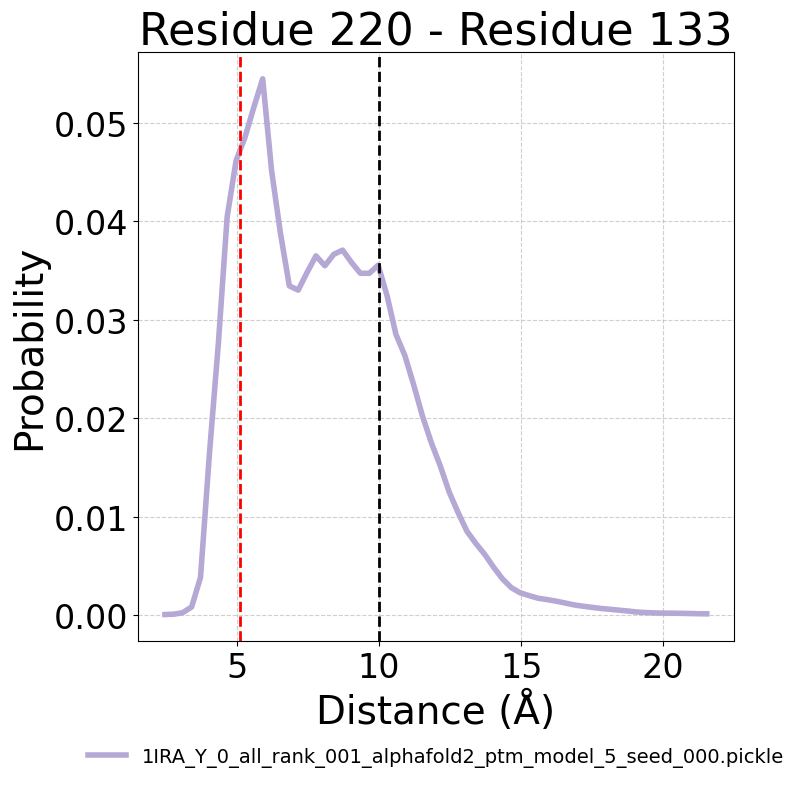

In [71]:
plot_distogram_line(
    ["/Volumes/Expansion/FEBS/af2-ptm/1IRA_Y/distograms/1IRA_Y_0_all_rank_001_alphafold2_ptm_model_5_seed_000.pickle"
    ],
    res_i=220,
    res_j=133,
    highlight_distances=[5.1, 10.0]
)

#### AF2.3

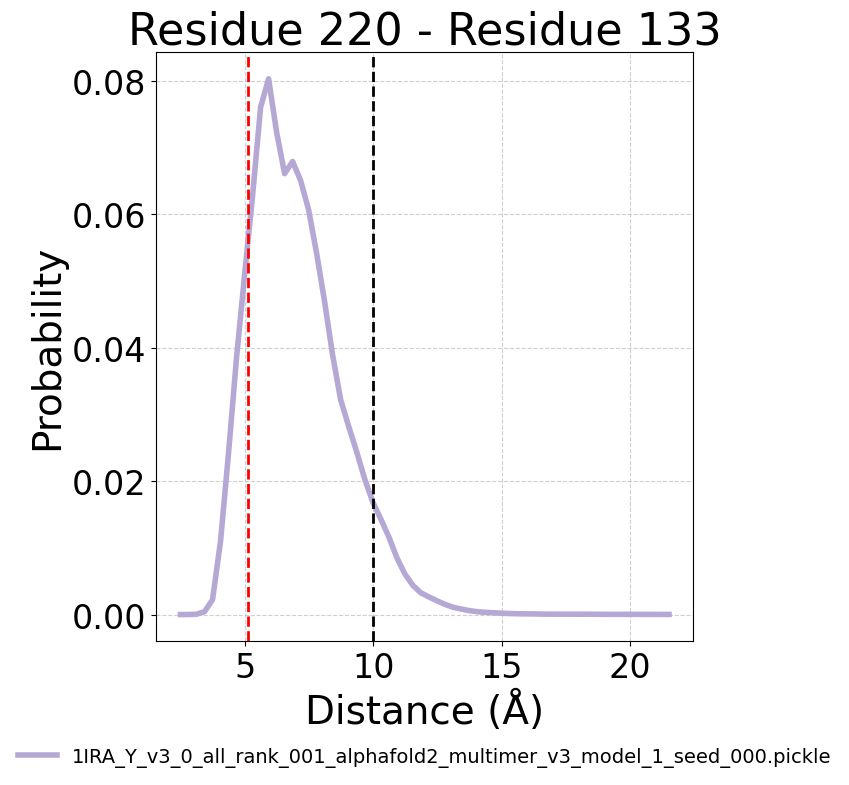

In [72]:
plot_distogram_line(
    ["/Volumes/Expansion/FEBS/af2.3/1IRA_Y/distograms/1IRA_Y_v3_0_all_rank_001_alphafold2_multimer_v3_model_1_seed_000.pickle"
    ],
    res_i=220,
    res_j=133,
    highlight_distances=[5.1, 10.0]
)

## MIA40 | Figure 4B

### All-to-all distogram for the 2-23th residues

#### AF2-ptm

In [ ]:
for res_id in range(2, 23):
    plot_distogram_for_a_residue(
        '/Volumes/Expansion/FEBS/af2-ptm/MIA40/distograms/mia40-ptm_0_all_rank_001_alphafold2_ptm_model_1_seed_000.pickle',
        res_id,
        save_fig=True,
        fig_name=f"/Volumes/Expansion/FEBS/af2-ptm/MIA40/all-to-all-dist-figs/all-distogram_residue_{res_id}_subplots.png"
    )

#### AF2.3

In [ ]:
for res_id in range(2, 23):
    plot_distogram_for_a_residue(
        '/Volumes/Expansion/FEBS/af2.3/MIA40/distograms/mia40_0_all_rank_001_alphafold2_multimer_v3_model_1_seed_000.pickle',
        res_id,
        save_fig=True,
        fig_name=f"/Volumes/Expansion/FEBS/af2.3/MIA40/all-to-all-dist-figs/all-distogram_residue_{res_id}_subplots.png"
    )


## EIF2B3 | Figure 4C

### All-to-all distogram for the 440-452th residues

#### AF2-ptm

In [ ]:
for res_id in range(440, 452):
    plot_distogram_for_a_residue(
        '/Volumes/Expansion/FEBS/af2-ptm/EIF2B3/distograms/eif2b3-ptm_0_all_rank_001_alphafold2_ptm_model_2_seed_000.pickle',
        res_id,
        save_fig=True,
        fig_name=f"/Volumes/Expansion/FEBS/af2-ptm/EIF2B3/all-to-all-dist-figs/all-distogram_residue_{res_id}_subplots.png"
    )


#### AF2.3

In [ ]:
for res_id in range(440, 452):
    plot_distogram_for_a_residue(
        '/Volumes/Expansion/FEBS/af2.3/EIF2B3/distograms/eif2b3_0_all_rank_001_alphafold2_multimer_v3_model_3_seed_000.pickle',
        res_id,
        save_fig=True,
        fig_name=f"/Volumes/Expansion/FEBS/af2.3/EIF2B3/all-to-all-dist-figs/all-distogram_residue_{res_id}_subplots.png"
    )


### Residue 445 vs 448

#### AF2-ptm

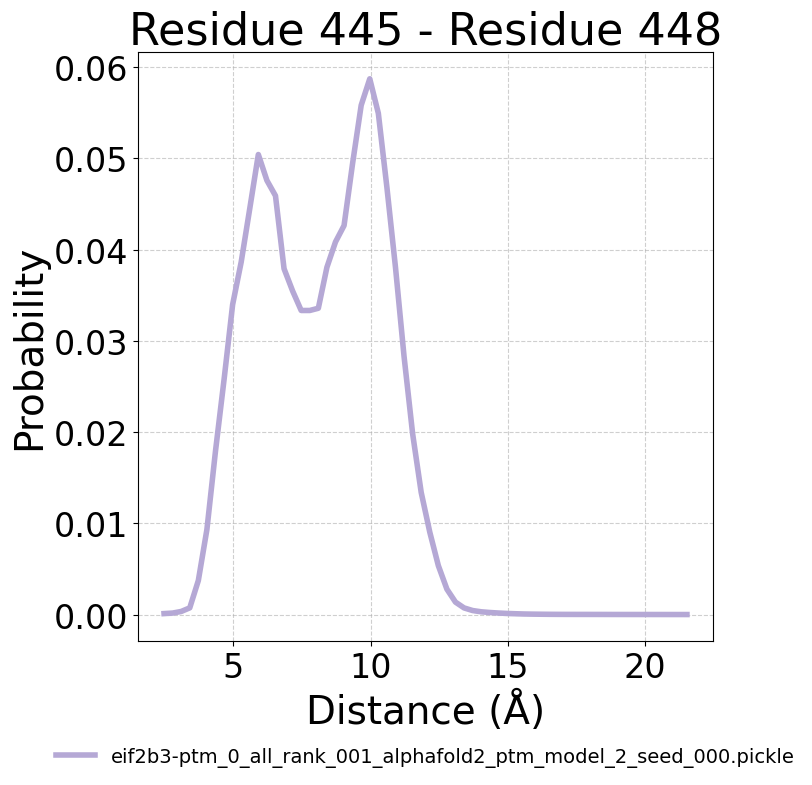

In [78]:
plot_distogram_line(
    ["/Volumes/Expansion/FEBS/af2-ptm/EIF2B3/distograms/eif2b3-ptm_0_all_rank_001_alphafold2_ptm_model_2_seed_000.pickle"
    ],
    res_i=445,
    res_j=448,
    #highlight_distances=[5.1, 10.0]
)

#### AF2.3

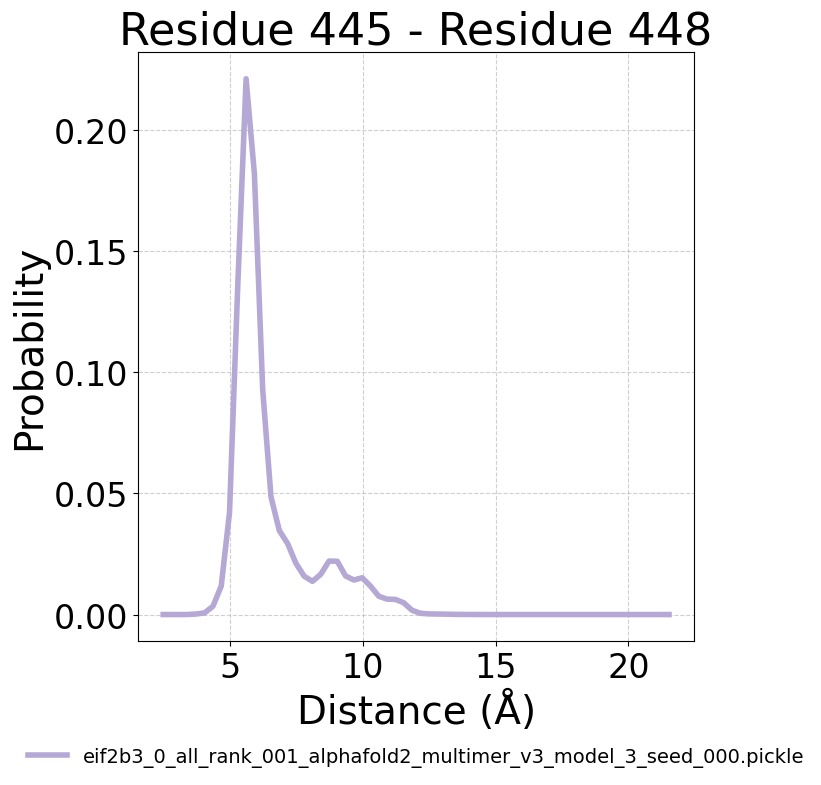

In [79]:
plot_distogram_line(
    ["/Volumes/Expansion/FEBS/af2.3/EIF2B3/distograms/eif2b3_0_all_rank_001_alphafold2_multimer_v3_model_3_seed_000.pickle"
    ],
    res_i=445,
    res_j=448,
    #highlight_distances=[5.1, 10.0]
)